<a href="https://www.manning.com/books/build-a-large-language-model-from-scratch">
<img src="px/bookcover.png" width="60%"></a>

In [3]:
from importlib.metadata import version

pkgs = [
    "matplotlib",  # Plotting library
    "tiktoken",    # Tokenizer
    "torch",       # Deep learning library
    "tqdm",        # Progress bar
    "tensorflow",  # For OpenAI's pretrained weights
]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.7
tiktoken version: 0.12.0
torch version: 2.9.1
tqdm version: 4.67.1
tensorflow version: 2.21.0


---
### 1 Understanding Large Language Models
---
- LLMs use __transformers__ to selectively pay attention to different parts of an input stream.
- LLMs are often called __generative AI__ due to their ability to generate text.

### 1.1 definitions
![fig1-1](px/fig1-1.png)
### 1.2 applications
![fig1-2](px/fig1-2.png)
### 1.3 build stages
![fig1-3](px/fig1-3.png)
- custom builds can outperform general-purpose LLMs.
- pretraining creates a _baseline_ model.
- finetuning (on labeled data) teaches text prediction.
- _instruction_ finetuning uses instruction:answer pairs as a labeled dataset.
- _classification_ finetuning uses text and class labels.

### 1.4 transformers
![fig1-4](px/fig1-4.png)

- ["attention is all you need"](https://arxiv.org/abs/1706.03762): intro of the transformer architecture.
- consists of an __encoder__ (text -> vector) and __decoder__ (vector -> text)
- self-attention: weightings of tokens in sequence relative positioning

![fig1-5](px/fig1-5.png)
- BERT = transformer variant (bidirectional)
	- specializes in __masked word prediction__.
	- X (twitter) uses BERT to see toxic content.
- GPTx = transformer variant
	- focuses on decoder --> designed for _generating_ texts.
 
![fig1-6](px/fig1-6.png)
- BERT and GPT are both good at __zero_shot__ & __few_shot__ learning.

### TRANSFORMERS VERSUS LLMS
- Transformers and LLMs are often used synonymously in the literature.
- Not all transformers are LLMs - transformers can also be used for computer vision. 
- Not all LLMs are transformers - some are based on recurrent and convolutional architectures.
- The motivation is to improve the computational efficiency of LLMs. Whether they can compete with the capabilities of transformer-based LLMs is TBD.
- For simplicity, this book uses "LLM" to refer to transformer-based LLMs similar to GPT.

### 1.5 datasets
GPT3 training data:

![table1-1](px/table1-1.png)

- Also see: [Dolma: open corpus, 3T tokens](https://arxiv.org/abs/2402.00159)

### 1.6 GPT architecture
- GPT stands for __Generative Pretrained Transformer__.
- GPT-3 is a scaled-up version of this model that has more parameters and was trained on a larger dataset.
- The original ChatGPT was created by finetuning GPT-3 on a large instruction dataset using a method from __OpenAI’s InstructGPT__ paper (see chapter 7).
- Next-word prediction is a form of __self-supervised learning__ (aka self-labeling). We don’t need to collect labels for the training data explicitly but can leverage the structure of the data itself: we can use the next word in a sentence or document as the label that the model is supposed to predict.
- Since this allows us to create labels “on the fly,” it is possible to leverage massive unlabeled text datasets to train LLMs.

![fig1-8](px/fig1-8.png)

- The general GPT architecture is relatively simple. It’s __just the decoder part__ without the encoder.
- Since decoder-style models like GPT generate text by predicting text one word at a time, they are considered a type of __autoregressive model__. Autoregressive models use previous outputs as inputs for future predictions. 
- Architectures such as GPT-3 are significantly larger than the original transformer model. For instance, the original transformer repeated the encoder and decoder blocks six times. GPT-3 has 96 transformer layers and 175 billion parameters in total.

### 1.7 build workflow
![fig1-9](px/fig1-9.png)

---
### 2 Working with Text Data
---
### 2.1 word embeddings
- __continuous-valued__ vectors
- __word-level embedding is most common__. sentence-, paragraph-, document-level embeds also used.
- sentence- & paragraph-level embeds = popular for __RAG__ (retrieval-augmented generation).
    - RAG combines text generation with retrieval (searching extern knowledge base)
 
<img src="px/fig2-3.png" width="500">

- __word2vec__: one of the earliest word embedding algorithms.
- LLMs commonly build their own embeddings.
- __dimensionality__, aka embedding size: smallest version of GPT2 = 768 dimensions (117M and 125M params); largest version of GPT-3 = 12288 dimensions (175B params).

### 2.2 tokenizing
- In this section: tokenize a 20K+ character short story into words and special characters, which we will convert to embeddings for LLM training.

<img src="px/fig2-4.png" width="400">
- the-verdict.txt (https://en.wikisource.org/wiki/The_Verdict)

### load sample short story

In [4]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
	raw_text = f.read()

print("#characters:", len(raw_text), "\n")
print(raw_text[:99])

#characters: 20480 

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [5]:
raw_text

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a rich widow, and established himself in a villa on the Riviera. (Though I rather thought it would have been Rome or Florence.)\n\n"The height of his glory"--that was what the women called it. I can hear Mrs. Gideon Thwing--his last Chicago sitter--deploring his unaccountable abdication. "Of course it\'s going to send the value of my picture \'way up; but I don\'t think of that, Mr. Rickham--the loss to Arrt is all I think of." The word, on Mrs. Thwing\'s lips, multiplied its _rs_ as though they were reflected in an endless vista of mirrors. And it was not only the Mrs. Thwings who mourned. Had not the exquisite Hermia Croft, at the last Grafton Gallery show, stopped me before Gisburn\'s "Moon-dancers" to say, with tears in her eyes: "We shall not look upon its like again"?\n\nWell!--even 

### use Python regex library to split text

In [6]:
import re 
t = "hello world, this is a test."
print(re.split(r'(\s)',t))

# split on whitespaces, commas, periods
print(re.split(r'([,.]|\s)',t))

# remove redundant whitespaces
print([item for item in re.split(r'([,.]|\s)',t) if item.strip()])

# also handle "?", quote marks, double-dashes
text = "Hello, world. Is this-- a test?"
result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result = [item.strip() for item in result if item.strip()]
print(result)

['hello', ' ', 'world,', ' ', 'this', ' ', 'is', ' ', 'a', ' ', 'test.']
['hello', ' ', 'world', ',', '', ' ', 'this', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']
['hello', 'world', ',', 'this', 'is', 'a', 'test', '.']
['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


### apply basic tokenizer to entire short story.
- should verify 4690 tokens.

In [7]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(len(preprocessed))

4690


### view first 30 tokens

In [8]:
print(preprocessed[:30])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


### 2.3 tokens to IDs
- Next: convert tokens from Python strings to __token IDs__ (integers).
- We need a __vocabulary__ to map tokens to IDs.

<img src="px/fig2-6.png" width="400">

### create a list of all unique tokens. print the first 10.

In [9]:
preprocessed = re.split(r'([,.?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(len(preprocessed))
print(preprocessed[:10])

4649
['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius']


In [10]:
all_words = sorted(set(preprocessed))
vocab_size = len(all_words)
print(vocab_size)

1159


In [11]:
vocab = {token:integer for integer,token in enumerate(all_words)}
for i, item in enumerate(vocab.items()):
	print(item)
	if i >= 30:
		break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)
('Burlington', 21)
('But', 22)
('By', 23)
('Carlo', 24)
('Carlo;', 25)
('Chicago', 26)
('Claude', 27)
('Come', 28)
('Croft', 29)
('Destroyed', 30)


### build a simple tokenizer (encoder and decoder) as a Python class
<img src="px/fig2-8.png" width='500'>

In [12]:
class SimpleTokenizerV1:

	def __init__(self, vocab):
		# store vocab as class attribute
		self.str_to_int = vocab 
		# create inverse vocab: maps tokens back to orig text tokens
		self.int_to_str = {i:s for s,i in vocab.items()}

	# converts text --> token IDs
	def encode(self, text):
		preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
		preprocessed = [
			item.strip() for item in preprocessed if item.strip()
		]
		ids = [self.str_to_int[s] for s in preprocessed]
		return ids
	
	# converts token IDs --> text
	def decode(self, ids):
		text = " ".join([self.int_to_str[i] for i in ids])
		# replaces spaces before specified punctuation
		text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
		return text

# tokenize a passage from the short story:
tokenizer = SimpleTokenizerV1(vocab)
text = """"It's the last he painted, you know," Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)

# turn these tokens back into text:
print(tokenizer.decode(ids))

[1, 58, 2, 872, 1013, 615, 541, 763, 5, 1155, 608, 5, 1, 69, 7, 39, 873, 1136, 773, 812, 7]
" It' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.


### apply to new sample. "Hello" not in vocabulary - bounces out with an error.

In [13]:
try:
    print(tokenizer.encode("Hello, do you like tea?"))
except Exception:
    print("sorry, but a word from this query is not in the vocabulary.")


sorry, but a word from this query is not in the vocabulary.


### 2.4 special context tokens
<img src="px/fig2-9.png" width="500">

- Common practice to insert tokens between document or book boundaries. This helps with training.

### modify vocab to include "junk" and "endoftext" tokens. 
- new vocab size should be 1161.
- [Python list "extend" function](https://www.w3schools.com/python/ref_list_extend.asp)

In [14]:
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])
vocab = {token:integer for integer,token in enumerate(all_tokens)}
print(len(vocab.items()))

# last 5 entries of updated vocab:
for i, item in enumerate(list(vocab.items())[-5:]):
	print(item)

1161
('younger', 1156)
('your', 1157)
('yourself', 1158)
('<|endoftext|>', 1159)
('<|unk|>', 1160)


### adjust tokenizer to handle these special tokens

In [15]:
class SimpleTokenizerV2:
	def __init__(self, vocab):
		self.str_to_int = vocab
		self.int_to_str = { i:s for s,i in vocab.items()}

	def encode(self, text):
		preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
		preprocessed = [
			item.strip() for item in preprocessed if item.strip()
		]
		# replaces unknown words with junk token
		preprocessed = [item if item in self.str_to_int
						else "<|unk|>" for item in preprocessed]

		ids = [self.str_to_int[s] for s in preprocessed]
		return ids

	def decode(self, ids):
		text = " ".join([self.int_to_str[i] for i in ids])
		# replaces spaces before specified punctuation
		text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
		return raw_text

text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."
text = " <|endoftext|> ".join((text1, text2))
print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


### tokenize
- note how 1159 corresponds to the end-of-text separator.
- note how 1160 corresponds to two unknown words ("Hello", "palace").

In [16]:
tokenizer = SimpleTokenizerV2(vocab)
print(tokenizer.encode(text))
print(tokenizer.decode(tokenizer.encode(text))[:100])

[1160, 5, 362, 1155, 642, 1000, 10, 1159, 57, 1013, 981, 1009, 738, 1013, 1160, 7]
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no g


### FYI:
- other special tokens: BOS (beginning of sequence), EOS (end of sequence), PAD (used to ensure all texts have same length).
- GPT doesn't use a junk token - uses BPE instead.

### 2.5 byte pair encoding (bpe)
- pip install [tiktoken](https://github.com/openai/tiktoken) [(example from OpenAI Cookbook)](https://github.com/openai/openai-cookbook/blob/main/examples/How_to_count_tokens_with_tiktoken.ipynb)
- instantiate BPE tokenizer using GPT-2 encoding
- endoftext token assigned to large id#
- BPE tokenizer handles unknown words w/o errors
	- breaks unknowns into subwords or characters
	- BPE builds vocab by merging frequent chars into subwords & frequent subwords into words.
	- merge frequency handled by a cutoff variable.

### usage similar to SimpleTokenizerV2.encode

In [17]:
from importlib.metadata import version
import tiktoken
print ("tiktoken vers#", version("tiktoken"))

tokenizer = tiktoken.get_encoding("gpt2")

text = (
"Hello, do you like tea? <|endoftext|> In the sunlit terraces"
"of someunknownPlace.")
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print("encoded integers:\n",integers)

strings = tokenizer.decode(integers)
print("decoded tokens:\n",strings)

tiktoken vers# 0.12.0


/home/bjpcjp/venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


encoded integers:
 [15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]
decoded tokens:
 Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


### notes:
- <|endoftext|> token is assigned to token# 50256. The BPE tokenizer (used on GPT-2, GPT-3 & orig GPT) has a vocabulary size of 50,257, with <|endoftext|> being assigned the largest token ID.
- BPE tokenizer encodes and decodes unknown words, such as "someunknownPlace" correctly. The BPE tokenizer can handle any unknown word. __How does it achieve this without using <|unk|> tokens?__
    - BPE breaks down words that aren't in its vocabulary into smaller subword units or even individual characters, enabling it to handle out-of-vocabulary words. So if the tokenizer encounters an unfamiliar word during tokenization, it can represent it as a sequence of subword tokens or characters:
 
<img src="px/fig2-11.png" width="500">

- BPE builds its vocabulary by __iteratively merging frequent characters__ into subwords and frequent subwords into words. It starts with adding all individual single characters to its vocabulary ("a", "b", ...). It next merges character combinations that frequently occur together into subwords.
- For example, "d" and "e" may be merged into the subword "de," which is common in many English words like "define", "depend", "made", and "hidden". The merges are determined by a frequency cutoff.

### 2.6 data sampling - sliding window
<img src="px/fig2-12.png" width="500">

### first: tokenize "the verdict" again with BPE

In [18]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
	raw_text = f.read()
enc_text = tokenizer.encode(raw_text)
print(len(enc_text))


5146


### remove first 50 tokens - demo purposes

In [19]:
enc_sample = enc_text[50:]
print(len(enc_sample))

5096


### create input:target pairs for next-word predictor
- context size = how many tokens are included in output
- y = inputs shifted by one position.

In [20]:
context_size = 4 
x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]
print(f"x: {x}")
print(f"y: {y}")

x: [290, 4920, 2241, 287]
y: [4920, 2241, 287, 257]


### create prediction task (input ----> output)

In [21]:
for i in range(1, context_size+1):
	context = enc_sample[:i]
	desired = enc_sample[i]
	print(context, "---->", desired)

[290] ----> 4920
[290, 4920] ----> 2241
[290, 4920, 2241] ----> 287
[290, 4920, 2241, 287] ----> 257


### repeat prediction with token IDs converted (decoded) to text

In [22]:
for i in range(1, context_size+1):
	context = enc_sample[:i]
	desired = enc_sample[i]
	print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a


### Now we need a data loader.

<img src="px/fig2-13.png" width="500">

### notes
- figure shows tokens as strings. BPE actually operates directly on IDs (tks to `encode`).
- use [PyTorch Dataset & DataLoader classes](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) to get started.

In [23]:
import torch
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
	def __init__(self, txt, tokenizer, max_length, stride):
		self.input_ids = []
		self.target_ids = []
		token_ids = tokenizer.encode(txt) #tokenize ENTIRE text

		# use sliding window to chunk book into OVERLAPPING sequences of max_length
		for i in range(0, len(token_ids) - max_length, stride):
			input_chunk  = token_ids[i:     i + max_length    ]
			target_chunk = token_ids[i + 1: i + max_length + 1]
            
			self.input_ids.append(torch.tensor(input_chunk))
			self.target_ids.append(torch.tensor(target_chunk))
	
	# return total #rows in dataset	
	def __len__(self):
		return len(self.input_ids)
	
	# return single row from dataset
	def __getitem__(self, idx): #D
		return self.input_ids[idx], self.target_ids[idx]

# BATCH SIZE = 4
# MAX LENGTH = 256
# STRIDE = 128
# SHUFFLE = True
# DROP LAST = True
# WORKERS = 0

def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
	tokenizer = tiktoken.get_encoding("gpt2") #init
	dataset = GPTDatasetV1(txt, tokenizer, max_length, stride) # create dataset
	dataloader = DataLoader(
		dataset,
		batch_size=batch_size,
		shuffle=shuffle,
		drop_last=drop_last, # drops last batch if shorter than batch_size (prevents training spikes)
		num_workers=0 # number of CPU processes
		)
	return dataloader

### test: batch size = 1, LLM context size = 4 (artificially low for demo purposes. >=256 is common.)
- returns input token IDs (tensor), and target token IDs (tensor).

In [24]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
	raw_text = f.read()

dataloader = create_dataloader_v1(
	raw_text, batch_size=1, max_length=4, stride=1, shuffle=False)

data_iter = iter(dataloader) # convert to python iterator (uses python next function)
first_batch = next(data_iter)
print("first batch:\n",first_batch)

first batch:
 [tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


<img src="px/fig2-14.png" width="500">

### 2nd batch output = shifted by one position
- stride sets number of positions to shift across batches.
- repeat with batch size > 1

In [25]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]


### how to use data loader to sample with batch size > 1
- `stride=4` helps use dataset more fully, and helps avoid overlap between batches (ie, overfit).

In [26]:
dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


### 2.7 token embeddings
- __embeddings are continuous-valued vectors__. They are init'd with random values.
- __embed layers__: a better way of doing __one-hot encoding__ followed by __mat.mul__ in a fully connected layer. [https://github.com/rasbt/LLMs-from-scratch/blob/main/ch02/03_bonus_embedding-vs-matmul/embeddings-and-linear-layers.ipynb]

<img src="px/fig2-15.png" size="500">

### illustration: token IDs --> embedding vector
- starts with input tokens; assume only 6 words in vocab; we want embeddings of size = 3.
- 6 rows (vocab size), 3 cols (3 dimensions aka features per vocab entry)

In [27]:
input_ids = torch.tensor([2,3,5,1])
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
print("embedding layer:\n", embedding_layer,"\n")
print("weights:\n",         embedding_layer.weight,"\n")
print("weights (4th row)\n",embedding_layer(torch.tensor([3])))

embedding layer:
 Embedding(6, 3) 

weights:
 Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True) 

weights (4th row)
 tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


### EMBEDDING LAYERS VERSUS MATRIX MULTIPLICATION
- This embedding layer approach is a more efficient way of doing __one-hot encoding__ followed by matrix multiplication in a __fully connected layer__ (see the GitHub at [https://github.com/rasbt/LLMs-from-scratch/tree/main/ch02/03_bonus_embedding-vs-matmul]). It can be seen as a neural network layer that can be optimized via backpropagation.

### apply token-to-vector conversion to all four input IDs

In [28]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)



<img src="px/fig2-16.png" width="500">

### 2.8 encoding word positions
- issue: self-attention __doesn't know how to handle positions or order__.
- previously: same token ID is always mapped to same vector - regardless of where token ID's input position.
<img src="px/fig2-17.png" size="500">
- position-aware embed types:
	- __relative__ position (aka distance btwn tokens)
	- __absolute__ position (specific positions in a sequence)
- GPT uses absolute position embedding, optimized during training.
- context_length = LLM's supportable input size.

<img src="px/fig2-18.png" size="500">

### new example: 
- output dimension size = 256 & vocab size = 50257 (from BPE tokenizer)

In [29]:
output_dim = 256
vocab_size = 50257
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

### get sample data from dataloader
- batch size = 8, 4 tokens each

In [30]:
max_length = 4
dataloader = create_dataloader_v1(
	raw_text, batch_size=8, max_length=max_length, stride=max_length, shuffle=False)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


### use embed layer to embed token IDs to 256-d vector.

In [31]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)

torch.Size([8, 4, 256])


### for GPT-style absolute encoding approach - create another embed layer with same dims

In [32]:
context_length      = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
pos_embeddings      = pos_embedding_layer(torch.arange(context_length))
print(pos_embeddings.shape)

# add positional embeddings to token embeddings
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

torch.Size([4, 256])
torch.Size([8, 4, 256])


---
### 3 (Self) Attention Mechanisms
---
<img src="px/fig3-2.png" size="500">

### 3.1 long-sequence problems
<img src="px/fig3-3.png" width="500">

- word-for-word language translation matching __isn't doable__ due to grammatical structure differences.
- before transformers, RNNs were most popular encode-decode architecture for translations.

<img src="px/fig3-4.png" width="500">

- RNN encoders & decoders use _hidden states_ (memory cell) to capture context info. RNNs rely on __entire__ current hidden state being available before passing to a decoder. Big limitation!

### 3.2 capturing data dependencies with attention mechanism
<img src="px/fig3-5.png" width="500">

- Before transformer LLMs, it was common to use RNNs for language translation. RNNs work fine for translating short sentences but not for longer texts - they don’t have direct access to previous words in the input.

### 3.3 self-attention
<img src="px/fig3-7.png" width="500">

- "self": ability to get weights from __different positions in a single input sequence__.
- traditional attention: focused on __relations between elements of two sequences__.

### 3.3.1 self attention - no trainable weights
- "x" input sequence of "T" elements - text already converted to token embeddings.
- each element corresponds to "d"-dimensioned vector for specific token.
- goal: find context vectors z_i for each element x_i in input sequence.

In [33]:
# sample sequence, already converted to 3D vectors. (small to prevent line breaks.)
import torch
inputs = torch.tensor(
[[0.43, 0.15, 0.89], # Your
[0.55, 0.87, 0.66], # journey
[0.57, 0.85, 0.64], # starts
[0.22, 0.58, 0.33], # with
[0.77, 0.25, 0.10], # one
[0.05, 0.80, 0.55]] # step
)

query         = inputs[1] # 2nd token serves as the query.
attn_scores_2 = torch.empty(inputs.shape[0])

# attention scores = dot product (query token, every input token).
for i, x_i in enumerate(inputs):
	attn_scores_2[i] = torch.dot(x_i, query)
print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


### DOT PRODUCTS
- __built by multiplying two vectors element-wise, then summing the products__. scalar value.
- They are __a measure of similarity - how much two vectors are aligned__. (higher = greater degree of alignment/similarity.)
- They measure __how elements in a sequence relate to each other__.

### normalize the attention weights (sum of weights = 1)
<img src="px/fig3-9.png" width="500">

In [34]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()
print("Attention weights:", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


### use the softmax function for normalization. 
- It's better at managing extreme values and has better gradient properties during training.
- Softmax also ensures __attention weights are always positive__. This makes the output interpretable as probabilities or relative importance (higher weights = greater importance).

In [35]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)
print("Attention weights:", attn_weights_2_naive)
print("Sum:", attn_weights_2_naive.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


### use the PyTorch implementation of softmax.
- The naive softmax implementation (above) may encounter overflow and underflow problems when dealing with large or small input values. 

In [36]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


### context vectors
- found by __multiplying embedded input tokens x(i) with corresponding attention weights__, then summing the results.
- 
<img src="px/fig3-10.png" width="80%">

In [37]:
query         = inputs[1] # 2nd input token is the query
context_vec_2 = torch.zeros(query.shape)

for i,x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i]*x_i
    
print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


### 3.3.2 - attention weights for all tokens
- same steps as before, except now we're computing all context vectors - not just z_2.
- Each element in the tensor is __an attention score between each pair of inputs__. 

In [38]:
attn_scores = torch.empty(6, 6)

for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)
        
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


### use matrix multiplication (instead of do loops = SLOW) to replicate results.

In [39]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


### normalize each row
- The `dim` parameter in functions like torch.softmax specifies the dimension of the tensor along which the function will be computed. `dim=-1` tells softmax to apply the normalization __along the last dimension of the tensor__. If attn_scores is a 2D tensor (for example, with a shape of [rows, columns]), `dim=-1` normalizes __across the columns__ (the values in each row (summing over the column dimension) sum up to 1.)

In [40]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


### verify rows all sum to 1:

In [41]:
row_2_sum = sum(attn_weights[1])
#row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
print("Row 2 sum:", row_2_sum)
print("All row sums:", attn_weights.sum(dim=-1))

Row 2 sum: tensor(1.)
All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


### use attention weights to compute all context vectors via matrix multiplication:

In [42]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


### verify code is correct by comparing 2nd row with the context vector z(2) 

In [43]:
print("Previous 2nd context vector:", context_vec_2)

Previous 2nd context vector: tensor([0.4419, 0.6515, 0.5683])


### 3.4 - attention with trainable weights (aka _scaled dot-product attention_)
- self-attention with trainable weights builds context vectors as weighted sums over the input vectors specific to a certain input element.
- It introduces __weight matrices__ that are updated during training. They enable the model (specifically the attention module) to learn how to produce “good” context vectors.

### 3.4.1 - step by step
- We will define __three trainable weight matrices__ `Wq, Wk, and Wv`. They are used to project the embedded input tokens, x(i), into query, key, and value vectors.

<img src="px/fig3-14.png" width="500">

- We earlier defined the __second input element x(2) as the query__ when we computed simplified attention weights to find the __context vector z(2)__.
- Later we generalized this to __find all context vectors z(1) ... z(T)__ for the input “Your journey starts with one step.”

### start by computing only one context vector, z(2). 
- Next we will modify the code to calculate all context vectors.

In [44]:
x_2   = inputs[1] #2nd input element
d_in  = inputs.shape[1] #input embed size
d_out = 2 # output embed size

print(x_2,d_in,d_out)

tensor([0.5500, 0.8700, 0.6600]) 3 2


### initialize Wq, Wk, Wv
- `requires_grad=False` reduces clutter in the outputs.
- use `requires_grad=True` when updating weights for training.

In [45]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

In [46]:
query_2 = x_2 @ W_query
key_2   = x_2 @ W_key
value_2 = x_2 @ W_value
print(query_2)

tensor([0.4306, 1.4551])


### WEIGHT PARAMETERS VS ATTENTION WEIGHTS
- "weight" is short for "weight parameters," the values of a neural network that are optimized during training. This is not to be confused with __attention weights__. They determine the extent to which a context vector depends on the different parts of the input.
- In summary, weight parameters are the fundamental, learned coefficients that define the network's connections. __Attention weights are dynamic, context-specific values__.

### get keys and values via matrix multiplication

In [47]:
keys   = inputs @ W_key
values = inputs @ W_value

print("keys.shape:", keys.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


### get attention score w_22

In [48]:
keys_2        = keys[1]
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(1.8524)


### generalize this step to all attention scores for a given query
- note how 2nd element matches w_22, above

In [49]:
attn_scores_2 = query_2 @ keys.T
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


### Next: get attention weights by scaling the attention scores and normalize them via softmax. 
- This time, __scale the attention scores__ by dividing them by __the square root of the embedding dimension of the keys__.

In [50]:
d_k            = keys.shape[-1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


#### SCALED-DOT PRODUCT ATTENTION

- normalization by the embedded dimension size __improves training performance by avoiding small gradients__.
- For instance, when scaling up the embedding dimension, which is typically greater than 1,000 for GPT-like LLMs, large dot products can result in __very small gradients during backpropagation__ due to softmax.
- As dot products increase, __softmax behaves more like a step function__ with gradients nearing zero. These small gradients can drastically slow down learning or cause training to stagnate.

### find the context vector as a weighted sum over the value vectors. 
- The __attention weights serve as a weighting factor__ for the importance of each value vector. We can use matrix multiplication to obtain the output in one step.

In [51]:
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


### 3.4.2 building a compact self-attention Python class
- __SelfAttention_v1__ initializes trainable weight matrices (`W_query`, `W_key`, `W_value`) for queries, keys, and values, each transforming the input dimension `d_in` to an output dimension `d_out`.
- `forward` computes attention scores by multiplying queries and keys, normalizing these scores using softmax.
- Finally, __create a context vector__ by weighting the values with these normalized attention scores.

In [52]:
import torch.nn as nn
class SelfAttention_v1(nn.Module):
    
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))
        
    def forward(self, x):
        keys         = x @ self.W_key
        queries      = x @ self.W_query
        values       = x @ self.W_value
        attn_scores  = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        context_vec  = attn_weights @ values
        return context_vec

### input contains six embedding vectors, so this results in a matrix storing the six context vectors
- notice how the 2nd row matches `context_vec_2`, above.

In [53]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


### self-attention mechanism, summarized

<img src="px/fig3-18.png" width="500">

- Self-attention transforms input vectors (X) with three weight matrices (`Wq`, `Wk`, and `Wv`).
- Find the __attention weight matrix__ using the resulting queries (`Q`) and keys (`K`).
- Using the __attention weights and values__ (`V`), find the __context vectors__ (`Z`).
- The 3D input tensor is simplified to a two-dimensional matrix in this example.

### improve SelfAttention_v1 by using PyTorch’s `nn.Linear` layers
- they can do matrix multiplication when the bias units are disabled.
- Also, `nn.Linear` has an __optimized weight initialization__ scheme - more stable and effective training.

In [54]:
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys         = self.W_key(x)
        queries      = self.W_query(x)
        values       = self.W_value(x)
        attn_scores  = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        context_vec  = attn_weights @ values
        return context_vec

### `SelfAttention_v1` & `SelfAttention_v2` give different outputs 
- they use __different initial weights for the weight matrices__, since `nn.Linear` uses a more sophisticated weight initialization scheme.

In [55]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


### 3.5 - hiding future words with causal attention

- Causal attention, aka __masked attention__, restricts a model to consider only __previous and current inputs__ in a sequence when processing any given token. (standard self-attention mechanism allows access to the entire input sequence at once.)
- It masks attention weights above the diagonal & normalizes the nonmasked attention weights so __the attention weights sum to 1 in each row__.

<img src="px/fig3-19.png" width="500">

### Step 1: find the attention weights

In [56]:
queries      = sa_v2.W_query(inputs) #A
keys         = sa_v2.W_key(inputs)
attn_scores  = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


### Step 2: use [`torch.tril`](https://pytorch.org/docs/stable/generated/torch.tril.html) to create a mask where the values above the diagonal are zero.
- Multiply the weights with the mask.

In [57]:
context_length = attn_scores.shape[0]
mask_simple    = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [58]:
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


### Step 3: renormalize the attention weights to sum up to 1 in each row. 
- We can do this by dividing each element in each row by the sum in each row.

In [59]:
row_sums           = masked_simple.sum(dim=1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


### INFORMATION LEAKAGE
- When we apply a mask and then renormalize the attention weights, it appears that information from future tokens (which we intend to mask) could still influence the current token because their values are part of the softmax calculation.
- When we renormalize the attention weights after masking, we’re __effectively recalculating the softmax over a smaller subset__ (since masked positions don’t contribute to the softmax value).
- The elegance of softmax is that despite initially including all positions in the denominator, after masking and renormalizing, the effect of the masked positions is nullified.
- In simpler terms, after masking and renormalization, the distribution of attention weights is as if it was calculated only among the unmasked positions to begin with. This ensures there’s no information leakage from future (or otherwise masked) tokens as we intended.

### Take advantage of softmax & implement masked attention weightings more efficiently in fewer steps.
- Softmax converts its inputs into a probability distribution. It __treats negative infinity values (-∞) as zero__. (because e∞ approaches 0.)
- We can design a better masking “trick” by __creating a mask with 1s above the diagonal and then replacing these 1s with negative infinity (-inf)__.

In [60]:
mask   = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


In [61]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


### 3.5.2 masking additional attention weights with dropout
- Dropout is a technique where __random hidden layer units are ignored during training__. This helps prevent overfitting by ensuring that a model does not become overly reliant on a specific set of hidden layer units.
- Dropout is __only used during training and is disabled afterward__.
- In transformer architectures like GPT, dropout in the attention mechanism is typically applied after two events:
    - After __calculating attention scores__
    - After __applying attention weights to value vectors__. (done here - more common approach.)
<img src="px/fig3-22.png" width="500">

### use a dropout rate of 50% (masking out half of the attention weights)
- we will use a 0.1-0.2 dropout rate when training GPT.
- for illustration: __apply PyTorch’s dropout implementation to a 6×6 tensor (all ones).

In [62]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
example = torch.ones(6, 6)
print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


- 50% dropout: half of the elements are randomly set to zero. To compensate, the remaining elements are scaled up by a factor of 1/0.5 = 2.
- This maintains the balance of the attention weights, ensuring that the average influence of the attention mechanism remains consistent during training and inference phases.
### apply dropout to the attention weights.

In [63]:
torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)


- The results may look different depending on your OS. See the PyTorch issue tracker at [https://github.com/pytorch/pytorch/issues/121595].

### 3.5.3 - designing a compact causal attention class
- __ensure the code can handle batches consisting of >1 input__ so `CausalAttention` can support the batch outputs produced by the data loader we designed earlier.

### design a simple input text example
- It returns a 3D tensor - two input texts, six tokens each, where each token is a 3D embedding vector.

In [64]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


### `CausalAttention` is similar to `SelfAttention`, except that we added the dropout and causal mask components.

- `__self.register_buffer()` can help. For instance, when we use `CausalAttention` in our LLM, __buffers are automatically moved to the appropriate device (CPU or GPU)__ along with our model. This means we don’t need to manually ensure these tensors are on the same device as your model parameters, avoiding device mismatch errors.

In [65]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out   = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout) #A

        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length),
            diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape #C
        keys                = self.W_key(x)
        queries             = self.W_query(x)
        values              = self.W_value(x)
        attn_scores         = queries @ keys.transpose(1, 2)
        
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)
        context_vec  = attn_weights @ values
        return context_vec

### The resulting context vector is a 3D tensor - each token is represented by a 2D embedding.

In [66]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca             = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs   = ca(batch)
print("context_vecs.shape:", context_vecs.shape)

context_vecs.shape: torch.Size([2, 6, 2])


### progress thus far:
<img src="px/fig3-23.png" width="75%">

### 3.6 extending single-head attention to __multi-head__ attention
- “multi-head” refers to dividing the attention mechanism into multiple independent “heads,” each operating independently. A single causal attention module can be considered single-head attention - there is __only one set of attention weights__ processing the input sequentially.
- First: stack multiple `CausalAttention` modules for illustration purposes. 
- Second: build a multi-head attention module in a more complicated but more computationally efficient way.

### 3.6.1 Stacking multiple single-head attention layers

<img src="px/fig3-24.png" width="65%">

- The idea behind multi-head attention is to run the attention mechanism multiple times (in parallel) __with different, learned linear projections__ — the results of multiplying the input data (like the query, key, and value vectors in attention mechanisms) by a weight matrix.

### design wrapper class to stack instances of `CausalAttention`

In [67]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(
        self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
            super().__init__()
            self.heads = nn.ModuleList(
                [CausalAttention(
                    d_in, d_out, context_length, dropout, qkv_bias)
                for _ in range(num_heads)])
        
    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)

- using `MultiHeadAttentionWrapper` with two attention heads (num_heads=2) and `CausalAttention` output dimension (d_out=2), returns 4D context vectors (d_out*num_heads=4).

<img src="px/fig3-25.png" width="70%">

In [68]:
torch.manual_seed(123)
context_length = batch.shape[1] # This is the number of tokens
d_in, d_out    = 3, 2
mha            = MultiHeadAttentionWrapper(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs   = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


- __context_vecs__:
    - 1st dimension = 2 (two input texts) (the input texts are duplicated, which is why the context vectors are identical).
    - 2nd dimension = 6 tokens in each input.
    - 3rd dimension = 4D embedding of each token.
- The single-head attention modules are processed sequentially by `forward`.

### 3.6.2 multi-head attention with weight splits
- combine `MultiHeadAttentionWrapper` and `CausalAttention` into a single `MultiHeadAttention` class.
- We will also make some multi-head attention optimizations.
- `MultiHeadAttentionWrapper` creates multiple heads with a list of `CausalAttention` objects (self.heads), each representing a separate attention head.
- `CausalAttention` runs the attention mechanism. Results from each head are concatenated.
- `MultiHeadAttention` splits inputs into multiple heads by reshaping the projected query, key, and value tensors, then combines the results.

In [69]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"
        
        self.d_out     = d_out
        self.num_heads = num_heads
        self.head_dim  = d_out // num_heads # reduces projection dim to match desired output dim
        self.W_query   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key     = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj  = nn.Linear(d_out, d_out) # linear layer to combine head outputs
        self.dropout   = nn.Dropout(dropout)
        
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1))
        
    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys                = self.W_key(x)           # tensor shape: (b, num_tokens, d_out)
        queries             = self.W_query(x)
        values              = self.W_value(x)

        # split matrix by adding a num_heads dimension
        # then unroll the last dim: (b,num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim).
        
        keys                =    keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values              =  values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries             = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # transpose from (b, num_tokens, num_heads, head_dim) to (b, num_heads, num_tokens, head_dim)
        keys        =    keys.transpose(1, 2)
        queries     = queries.transpose(1, 2)
        values      =  values.transpose(1, 2)
        
        attn_scores = queries @ keys.transpose(2, 3)  # dot product for each head
        mask_bool   = self.mask.bool()[:num_tokens, :num_tokens] #masks truncated to number of tokens

        attn_scores.masked_fill_(mask_bool, -torch.inf) # use mask to fill attention scores
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec  = (attn_weights @ values).transpose(1, 2)  # shape: b, num_tokens, n_heads, head_dim

        # Combines heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)

        # Adds an optional linear projection
        context_vec = self.out_proj(context_vec)
        return context_vec

<img src="px/fig3-26.png" width="60%">

- The splitting of the query, key, and value tensors is done by tensor reshaping and transposing operations (using PyTorch’s __.view__ and __.transpose__ methods). The
input is first transformed (via linear layers for queries, keys, and values) and then reshaped to represent multiple heads.
- The key operation is to __split the d_out dimension into num_heads and head_dim__ (head_dim = d_out / num_heads).
- This splitting is done using __.view__: a tensor of dimensions (b, num_tokens, d_out) is reshaped to dimension (b, num_tokens, num_heads, head_dim).
- The tensors are then transposed to bring the num_heads dimension before the num_tokens dimension, resulting in a shape of (b, num_heads, num_tokens, head_dim).
- This transposition is crucial for correctly aligning the queries, keys, and values across the different heads and performing batched matrix multiplications efficiently.

### illustration: batched matrix multiplication
- The shape of this tensor is (b, num_heads, num_tokens, head_dim) = (1, 2, 3, 4).

In [70]:
a = torch.tensor([[
    [
        [0.2745, 0.6584, 0.2775, 0.8573],
        [0.8993, 0.0390, 0.9268, 0.7388],
        [0.7179, 0.7058, 0.9156, 0.4340]],
    [
        [0.0772, 0.3565, 0.1479, 0.5331],
        [0.4066, 0.2318, 0.4545, 0.9737],
        [0.4606, 0.5159, 0.4220, 0.5786]]]])

### batched matrix multiplication between the tensor and a view of the tensor where we transpose the last two dimensions (num_tokens and head_dim).

In [71]:
print(a @ a.transpose(2, 3))

tensor([[[[1.3208, 1.1631, 1.2879],
          [1.1631, 2.2150, 1.8424],
          [1.2879, 1.8424, 2.0402]],

         [[0.4391, 0.7003, 0.5903],
          [0.7003, 1.3737, 1.0620],
          [0.5903, 1.0620, 0.9912]]]])


- PyTorch matrix multiplication handles the 4D input tensor so that the matrix multiplication is carried out between the two last dimensions (num_tokens, head_dim) and then repeated for the individual heads.
- This becomes a more compact way to compute the matrix multiplication for each head separately.
- The results match those using the batched matrix multiplication print(a @ a.transpose(2, 3)) (above).

In [72]:
first_head = a[0, 0, :, :]
first_res  = first_head @ first_head.T
print("First head:\n", first_res)

second_head = a[0, 1, :, :]
second_res  = second_head @ second_head.T
print("\nSecond head:\n", second_res)

First head:
 tensor([[1.3208, 1.1631, 1.2879],
        [1.1631, 2.2150, 1.8424],
        [1.2879, 1.8424, 2.0402]])

Second head:
 tensor([[0.4391, 0.7003, 0.5903],
        [0.7003, 1.3737, 1.0620],
        [0.5903, 1.0620, 0.9912]])


- After computing the attention weights and context vectors, __the context vectors from all heads are transposed back to the shape (b, num_tokens, num_heads, head_dim)__. They are then reshaped (flattened) into the shape (b, num_tokens, d_out) - effectively combining the outputs from all heads.
- We added an output projection layer (`self.out_proj`) to `MultiHeadAttention` after combining the heads - which is not present in `CausalAttention`. This layer is not strictly necessary (see the References section in appendix B), but is commonly used in many LLM architectures, which is why we added it here for completeness.
- Even though `MultiHeadAttention` looks more complicated than `MultiHeadAttentionWrapper`, it is more efficient - we only need one matrix multiplication to compute the keys. The same is true for the queries and values).
- `MultiHeadAttentionWrapper` needs to repeat this matrix multiplication (computationally one of the most expensive steps), for each attention head.

### use `multiheadattention` similarly to `selfattention` and `causalattention`

In [73]:
torch.manual_seed(123)
batch_size, context_length, d_in = batch.shape
d_out                            = 2
mha                              = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)

context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])


- While `MultiHeadAttention` is functional, we used small embedding sizes and numbers of attention heads to keep the outputs readable.
- The smallest GPT-2 model (117M parameters) has 12 attention heads and a context vector embedding size of 768. The largest GPT-2 model (1.5B parameters) has 25 attention heads and a context vector embedding size of 1,600.
- Note: the embedding sizes of the token inputs and context embeddings are the same in GPT models (d_in = d_out).

---
### 4 Implementing a GPT model from Scratch To Generate Text
---

### 4.1 Coding an LLM architecture

<img src="px/fig4-2.png" width="60%">

### GPT-2 VS. GPT-3
- We are focusing on GPT-2 - OpenAI's pretrained model weights are publicly available.
- GPT-3 scales from 1.5B params (GPT-2) to 175B params & was trained on more data. As of July'24 GPT-3 weights are not publicly available.
- GPT-2 can be run on a single laptop. GPT-3 requires a GPU cluster for training and inference.
- According to Lambda Labs, it would take 355 years to train GPT-3 on a single V100 datacenter GPU and 665 years on a consumer RTX 8000 GPU.

### specify config variables in a Python dict

In [74]:
GPT_CONFIG_124M = {
    "vocab_size": 50257, # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768, # Embedding dimension
    "n_heads": 12, # Number of attention heads
    "n_layers": 12, # Number of layers
    "drop_rate": 0.1, # Dropout rate to prevent overfitting
    "qkv_bias": False # Query-Key-Value bias. Revisit this topic in chapter 6.
}

### design a GPT placeholder architecture using PyTorch `nn.Module`
- It consists of token and positional embeddings, dropout, a series of transformer blocks (`DummyTransformerBlock`), a final layer normalization (`DummyLayerNorm`), and a linear output layer (`out_head`).
- The configuration is passed in via a Python dictionary.
- `forward` describes the data flow through the model. It computes token and positional embeddings for the inputs, applies dropout, processes the data through the transformers, applies normalization, then produces logits with the linear output layer.
- We are using placeholders (`DummyLayerNorm` and `DummyTransformerBlock`) for now.

In [75]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb    = nn.Embedding(cfg["vocab_size"],     cfg["emb_dim"])
        self.pos_emb    = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb   = nn.Dropout(cfg["drop_rate"])

        # placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg)
            for _ in range(cfg["n_layers"])])

        # placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds          = self.tok_emb(in_idx)
        pos_embeds          = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x                   = tok_embeds + pos_embeds
        x                   = self.drop_emb(x)
        x                   = self.trf_blocks(x)
        x                   = self.final_norm(x)
        logits              = self.out_head(x)
        return logits

# placeholder - will be replaced by TransformerBlock later
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    # does nothing - just returns input.
    def forward(self, x):
        return x

# placeholder - will be replaced by TransformerBlock later
class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5): #The parameters here are just to mimic the LayerNorm interface.
        super().__init__()
    
    def forward(self, x):
        return x


<img src="px/fig4-4.png" width="60%">

### Tokenize a batch of two text inputs using tiktoken
- 1st & 2nd rows of result correspond to 1st and 2nd texts (see below).

In [76]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch     = []
txt1      = "Every effort moves you"
txt2      = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


### create a new 124M parameter DummyGPTModel instance and feed it the tokenized batch. 
- The outputs are commonly known as "logits".
- The output tensor has two rows corresponding to the two text samples.
- Each text sample has four tokens; each token is a 50,257-dimensional vector (matching the size of the tiktoken’s vocabulary).

In [77]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


### 4.2 Normalizing activations with layer normalization (LN)
- Training is __subject to vanishing or exploding gradient__ problems. They lead to unstable training dynamics and make it difficult for the network to effectively adjust its weights, which means the learning process struggles to find a set of parameters (weights) that minimizes the loss function. 
- Layer normalization adjusts the activations (outputs) of a layer to have a __mean of 0 and a variance of 1__, (aka unit variance). It speeds up the convergence to effective weights and ensures consistent, reliable training. LN is typically applied before and after the multi-head attention module and before the final output layer.

<img src="px/fig4-5.png" width="60%">

### example: create a layer with 5 inputs and 6 outputs, applied to two input examples.

In [78]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5)
layer         = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out           = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


- The Linear layer is followed by a __nonlinear activation function__ `ReLU` ("rectified linear unit"). ReLUs clamp negative inputs to 0, ensuring that a layer outputs only positive values, which is why the outputs do not contain negative values.

In [79]:
mean = out.mean(dim=-1, keepdim=True)
var  = out.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


- `keepdim=True` ensures the output tensor __retains the same number of dimensions as the input tensor__, even though the operation reduces the tensor along the `dim` dimension. Otherwise the returned mean tensor would be a 2D vector [0.1324, 0.2170] instead of a 2×1 matrix [[0.1324], [0.2170]].

<img src="px/fig4-6.png" width="60%">

- For a 2D tensor (like a matrix), using dim=-1 for operations such as mean or variance calculation __is the same as using dim=1__. This is because __-1 refers to the tensor’s
last dimension__, (columns in a 2D tensor).
- Later, when adding layer normalization to the GPT model, which produces 3D tensors with shape [batch_size, num_tokens, embedding_size], we can still use dim=-1 for normalization across the last dimension, avoiding a change from dim=1 to dim=2.

### Next: apply LN to the layer outputs 
- by subtracting the mean and dividing by the square root of the variance (also known as standard deviation). 
- This results in means near zero, and variances of one.

In [80]:
out_norm = (out - mean) / torch.sqrt(var)
mean     = out_norm.mean(dim=-1, keepdim=True)
var      = out_norm.var(dim=-1, keepdim=True)

print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


### repeating the above with scientific notation disabled

In [81]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


### design a normalization class
- This design operates on the last dimension of the input tensor x = embedding dimension (emb_dim).
- `eps` (epsilon) is a small constant added to the variance to prevent division by zero during normalization.
- `scale` and `shift` are params that the LLM automatically adjusts during training if doing so would improve the model’s training performance.

In [82]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps   = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean   = x.mean(dim=-1, keepdim=True)
        var    =  x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

### BIASED VARIANCE
- above: we set `unbiased=False`.
- we find variance by dividing by the number of inputs (n). This approach does not apply __Bessel’s correction__, which typically uses n – 1 instead of n in the denominator to adjust for bias in sample variance estimation. This results in a "biased estimate" of the variance.
- For LLMs, where the embedding dimension n is large, the difference between using n and n–1 is practically negligible. This approach ensures compatibility with the GPT-2 model’s normalization layers. It also reflects TensorFlow’s default behavior, which was used to implement the original GPT-2 model. Using a similar setting ensures our method is compatible with the pretrained weights we will load in chapter 6.

### apply LN to our batch input

In [83]:
ln     = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean   = out_ln.mean(dim=-1, keepdim=True)
var    = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


### LAYER NORMALIZATION (LN) VS. BATCH NORMALIZATION
- batch normalization is a common method for neural networks. Unlike batch normalization, which normalizes across the batch dimension, __LN normalizes across the feature dimension__.
- LLMs usually need significant computational resources - the hardware or use case can dictate the batch size during training or inference.
- Since LN normalizes inputs independent of batch size, it offers more flexibility.

### 4.3 - feed forward networks with GELU activations
- __ReLU__ has been commonly used due to its simplicity and effectiveness. Several others are also available:
    - __GELU__ (Gaussian error linear unit) and __SwiGLU__ (Swish-gated linear unit).
- GELU and SwiGLU use Gaussian and sigmoid-gated linear units, respectively. They offer improved performance.
- GELU can be implemented in several ways; the exact version is defined as GELU(x) = xΦ(x), where Φ(x) is the cumulative distribution function of the standard Gaussian distribution.
- It’s common to implement a computationally cheaper approximation (the original GPT-2 model was also trained with this approximation).

<img src="px/GELU.png" width="60%">

In [84]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

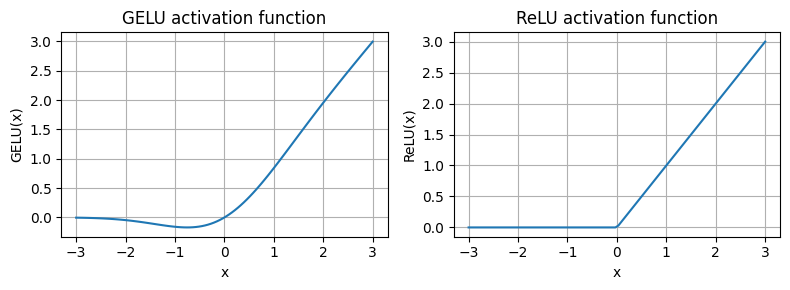

In [85]:
import matplotlib.pyplot as plt

gelu, relu     = GELU(), nn.ReLU()
x              = torch.linspace(-3, 3, 100) #A
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
    
plt.tight_layout()
plt.show()

- GELU aids optimization properties during training - it allows for more nuanced adjustments to the model’s parameters. ReLU has a sharp corner at zero, which can sometimes make optimization harder, especially in networks that are very deep or have complex architectures.
- GELU returns a small, non-zero output for negative values. This means neurons that receive negative input can still contribute to the learning process, albeit to a lesser extent than positive inputs.

### use GELU to build the small `FeedForward` neural network class

In [86]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

- __FeedForward__ contains two Linear layers and a GELU activation function. In the 124M parameter GPT model, it receives input batches with tokens with an embedding size of 768 each (`GPT_CONFIG_124M["emb_dim"] = 768`.)

<img src="px/fig4-9.png" width="60%">

### build a FeedForward module with a token embedding size of 768.
- feed it a batch input with two samples and three tokens each.

In [87]:
ffn = FeedForward(GPT_CONFIG_124M)
x   = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


- `FeedForward` __expands the embedding dimension into a higher-dimensional space through the first linear layer__. This is followed by a GELU activation, then a __contraction__ back to the original dimension. This enables exploration of a richer feature space.

<img src="px/fig4-10.png" width="60%">

- Uniformity in input and output dimensions also simplifies the architecture by __enabling the stacking of multiple layers__ without needing to adjust dimensions between them, thus making the model more scalable.

### 4.4 shortcut connections
- Shortcut connections (aka "skip" or "residual" connectons) were originally proposed for computer vision applications to mitigate the challenge of __vanishing gradients__. They create __alternative, shorter paths__ for the gradient to flow through the network by skipping one or more layers (adding the output of one layer to the output of a later layer).

<img src="px/fig4-12.png" width="60%">

### design a network class to optionally add shortcut connections to the `forward` method
- 5 layers, each consisting of a Linear layer & a GELU activation.
- `forward` passes inputs through the layers & optionally adds shortcuts if `self.use_shortcut` is `True`.

In [88]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers       = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])
        
    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x) # get output of current layer
            if self.use_shortcut and x.shape == layer_output.shape: # can shortcut be applied?
                x = x + layer_output
            else:
                x = layer_output
        return x

### Build a net __without__ shortcut connections. 
- Each layer is designed to accept an example with three inputs & returns three outputs. The last layer returns a single output value.

In [89]:
layer_sizes  = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)

### Design a function to find backward pass gradients
- When calling `loss.backward()`, PyTorch computes the loss gradient for each layer in the model.
- We can iterate through the weight parameters via `model.named_parameters()`.
- Suppose we have a 3×3 weight matrix for a given layer. This layer will have 3×3 gradient values, and we print the mean absolute gradient of these 3×3 gradient values to obtain a single gradient value per layer to compare the gradients between layers more easily.
- `.backward()` computes loss gradients, which are required during model training, without implementing the math for the gradient calculation ourselves.

In [90]:
def print_gradients(model, x):
    
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])
    
    # Calculate loss based on how close the target and output are
    loss = nn.MSELoss()
    loss = loss(output, target)
    
    # Backward pass to calculate the gradients
    loss.backward()
    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

### apply `print_gradients` to the model without skip connections:

In [91]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


### apply model __with__ skip connections for comparison

In [92]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694105327129364
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


- Notice the last layer (layers.4) has a larger gradient than the others. However, the __gradient stabilizes__ as we progress toward the first layer (layers.0) and doesn’t shrink to a vanishingly small value.

### 4.5 transformer blocks
- The transformer block combines several concepts: multi-head attention, layer normalization, dropout, feed forward layers, and GELU activations.

<img src="px/fig4-13.png" width="60%">

- When a transformer processes an input sequence, each element in the sequence is represented by a fixed-size vector (in this case, 768 dimensions). The operations are designed to transform these vectors in a way that preserves their dimensionality.
- The __self-attention__ mechanism in the multi-head attention block __finds relationships between elements__ while the feed forward network modifies the data individually at each position.

In [93]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=          cfg["emb_dim"],
            d_out=         cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=     cfg["n_heads"],
            dropout=       cfg["drop_rate"],
            qkv_bias=      cfg["qkv_bias"])
        
        self.ff            = FeedForward(cfg)
        self.norm1         = LayerNorm(cfg["emb_dim"])
        self.norm2         = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x # shortcut for attn block
        x        = self.norm1(x)
        x        = self.att(x)
        x        = self.drop_shortcut(x)
        x        = x + shortcut # Add the original input back
        shortcut = x # shortcut for feed fwd block
        x        = self.norm2(x)
        x        = self.ff(x)
        x        = self.drop_shortcut(x)
        x        = x + shortcut # add back original input
        return x

- This defines a `TransformerBlock` class with multi-head attention (`MultiHeadAttention`) and a feed forward network (`FeedForward`).
- `LayerNorm` is applied first. `Dropout` is applied afterwards to regularize the model and prevent overfitting. (This is also known as `Pre-LayerNorm`.)
- Older architectures, such as the original transformer model, applied layer normalization after the self-attention and feed forward networks instead (aka `Post-LayerNorm`), which often led to worse training dynamics.
- The class also defines `forward`, where each component is followed by a shortcut connection that adds the input of the block to its output.
  
### create a transformer block and feed it sample data.

In [94]:
torch.manual_seed(123)
x      = torch.rand(2, 4, 768)
block  = TransformerBlock(GPT_CONFIG_124M)
output = block(x)
print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


- __shape preservation throughout the transformer block is crucial__. It enables uses across a wide range of sequence-to-sequence tasks, where each output vector directly corresponds to an input vector.
- The output is a context vector that __holds information from the entire input sequence__. This means that while the length and feature size remain unchanged, the content of each output vector is re-encoded to integrate
contextual information from across the entire input sequence.

### 4.6 Coding the GPT model
- We started with an overview of a GPT architecture ("DummyGPTModel"). We showed the inputs and outputs, but its building blocks remained a black box using placeholder __DummyTransformerBlock__ and __DummyLayerNorm__ classes.

<img src="px/fig4-15.png" width="60%">

- Note how the transformer block is repeated throughout the model. It’s repeated 12 times (specified by `n_layers` in the config) in GPT-2 (124M params), and 36 times in GPT-2 (1542M params).
- The output from the final transformer block is fed to a __final layer normalization__ step before reaching the linear output layer. This layer maps the transformer’s output to a high-dimensional space (in this case, 50,257 dimensions, corresponding to the model’s vocabulary size) to predict the next token in the sequence.

In [95]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb    = nn.Embedding(cfg["vocab_size"],     cfg["emb_dim"])
        self.pos_emb    = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb   = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)
    
    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds          = self.tok_emb(in_idx)
        pos_embeds          = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)) # device setting: CPU or GPU
        
        x      = tok_embeds + pos_embeds
        x      = self.drop_emb(x)
        x      = self.trf_blocks(x)
        x      = self.final_norm(x)
        logits = self.out_head(x)
        return logits

- `init` initializes the token and positional embedding layers using the config dict. The embedding layers convert input token indices into dense vectors and adding positional information.
- next, `init` creates a sequential stack of `TransformerBlock` modules.
- Then a `LayerNorm` layer is built. It standardizes the transformer outputs to stabilize learning.
- Finally, a `Linear` output head without bias is defined. It projects the transformer’s output into the vocabulary space of the tokenizer to generate logits for each token in the vocabulary.

- `forward` does the following:
    1. finds the embeddings of a batch of input token indices
    2. applies positional embeddings
    3. passes the sequence through the transformer blocks (`trf_blocks`)
    4. normalizes the final output
    5. computes the logits (the next token’s unnormalized probabilities)

### next: initialize the 124M param GPT model

In [96]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out   = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


- The output tensor has the shape [2, 4, 50257]. (two input texts, four tokens each, 50257 vocabulary size.)

### let’s analyze the size of the model architecture
- `numel()` (“number of elements”) will help.

In [97]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


- Why 163M, not 124M?
- The original GPT2 used a concept called __weight tying__. It means the architecture is __reusing the weights__ from the token embedding layer in its output layer.

### review the shapes of the token embedding layer and linear output layer

In [98]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


### remove the output layer parameter count from the total GPT-2 model count

In [99]:
total_params_gpt2 = (
    total_params - sum(p.numel()
    for p in model.out_head.parameters()))
print(f"Number of trainable parameters "
f"considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


- Now the model has 124M parameters - matching the original size.
- __Weight tying reduces memory footprint and computational complexity__.
- Using separate token embedding and output layers results in better training and model performance; hence, we use separate layers in our design.
- The same is true for modern LLMs. However, we will revisit and implement the weight tying concept later.

### memory requirements of the 163M parameters in our GPTModel object
- assumes using float32 = 4 bytes per parameter

In [100]:
total_size_bytes = total_params * 4
total_size_mb    = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


### 4.7 Generating text

<img src="px/fig4-16.png" width="60%">

- By the sixth iteration, the model has constructed a complete sentence: “Hello, I am a model ready to help.”
- How does a GPT model go from output tensors tensors of shape [batch_size, num_token, vocab_size] to generated text?
- In each step, __the model outputs a matrix with vectors representing potential next tokens__. The vector corresponding to the next token is extracted and converted into a probability distribution via softmax function.
- Within the vector containing the resulting probability scores, __the index of the highest value is located, which translates to the token ID__. This token ID is decoded back to text, producing the next token in the sequence.
- Finally, this token is __appended to the previous inputs__, forming a new sequence for the next iteration.

In [101]:
def generate_text_simple(model, idx, max_new_tokens, context_size):

    for _ in range(max_new_tokens):

        # crop current context if larger than supported context size
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        # focus on last time step, so (batch, n_token, vocab_size)
        # becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # probas has shape (batch, vocab_size)
        probas = torch.softmax(logits, dim=-1)

        # idx_next has shape (batch,1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)

        # appends sampled index to running sequence.
        # idx has shape (batch, n_tokens+1)
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

- `generate_text_simple` iterates for a specified number of new tokens to be generated, crops the current context to fit the model’s maximum context size, computes predictions, and then selects the next token based on the highest probability prediction.
- `softmax` converts logits into probability distributions. `argmax` identifies the position with the highest value.
- `softmax` is monotonic (it preserves the order of its inputs when transformed into outputs), so in practice the softmax step is redundant - the position with the highest score in the softmax output tensor is the same position in the logit tensor. (In other words we could apply `argmax` to the logits tensor directly and get identical results.)
- However, this illustrates the full process of transforming logits to probabilities, which can add additional intuition so that the model generates the most likely next token, which is known as __greedy decoding__.

### encode example input context into token IDs

In [102]:
start_context  = "Hello, I am"
encoded        = tokenizer.encode(start_context)
encoded_tensor = torch.tensor(encoded).unsqueeze(0) # adds batch dimension

print("encoded:", encoded)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


### use `.eval() mode` to disable random components like dropout (only used during training)
- and use `generate_text_simple` on the encoded input tensor:

In [103]:
model.eval() # disables dropout, since we aren't training
out = generate_text_simple(
    model          = model,
    idx            = encoded_tensor,
    max_new_tokens = 10,
    context_size   = GPT_CONFIG_124M["context_length"])

print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267,
         49706, 43231, 47062, 34657]])
Output length: 14


### convert IDs back into text using `.decode`.

In [104]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue logger Normandy Compton analogous


- The model generated gibberish because we haven’t trained it yet. (we created a GPT model instance with __initial random weights__).

---
### 5 Pretraining on Unlabeled Data
---
<img src="px/fig5-1.png" width="60%">

### WEIGHT PARAMETERS
- Weights are trainable (learnable) parameters. In frameworks like PyTorch, weights are stored in __linear layers__.
- `torch.nn.Linear(...))` let us access its weights via `new_layer.weight`.
- PyTorch allows direct access to all a model’s trainable parameters, including weights and biases, via `model.parameters()`.

### 5.1 Evaluating generative text models
<img src="px/fig5-2.png" width="60%">

### 5.1.1 Using GPT to generate text
- Begin by initializing a GPT model using `GPTModel` and `GPT_CONFIG_124M`.

In [105]:
#import torch
#from chapter04 import GPTModel
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256, # shortened from 1024
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1, # common setting: 0
    "qkv_bias": False
}
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

- We've reduced the context length to 256 tokens. This reduces the computational demands of training the model.
- GPT-2 with 124M params was originally configured to handle up to 1,024 tokens. After training we will update the context size & load pretrained weights to work with a model with a 1,024-token context length.

<img src="px/fig5-3.png" width="60%">

### define `text_to_token_ids` and `token_ids_to_text`.


In [106]:
import tiktoken
#from chapter04 import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded        = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    # .unsqueeze(0) adds the batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # Remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer     = tiktoken.get_encoding("gpt2")
token_ids     = generate_text_simple(
    model          = model, 
    idx            = text_to_token_ids(start_context, tokenizer),
    max_new_tokens = 10,
    context_size   = GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


- The model is still producing gibberish. We need a __loss_metric__ to evaluate the generated content.

### 5.1.2 Calculating the text generation loss

<img src="px/fig5-6.png" width="60%">

- The above figure displays __softmax values for a simple seven-token vocabulary__. This implies the starting random values will hover around 1/7 (~0.14). 
- Text evaluation measures “how far” the tokens are from the correct predictions (targets).
- Training functions use the distance to adjust model weights by __increasing the softmax probability in the index positions corresponding to the correct target tokens__.
- Softmax also assesses the model’s generated outputs: the higher the probability, the better.
- GPT-2 model vocabulary has 50,257 tokens, so the initial probabilities will start at ~0.00002.

### Consider two inputs already mapped to token IDs and matching targets. 
- (targets = inputs, shifted one position forward.)

In [107]:
inputs = torch.tensor([[16833, 3626, 6100], # ["every effort moves",
                        [40, 1107, 588]]) # "I really like"]
targets = torch.tensor([[3626, 6100, 345 ], # [" effort moves you",
                        [588, 428, 11311]]) # " really like chocolate"]

### Feed inputs into model to find logits vectors. (2x3 tokens each.)
- Apply softmax on logits - returns prob scores (probas).
- 2 = two examples in the inputs = batch size.
- 3 = number of tokens per input.
- 50257 = embedding dimension = vocabulary size.

In [108]:
with torch.no_grad(): # disable gradient tracking (not training yet)
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1) #prob of each token in vocabulary
print(probas.shape)

torch.Size([2, 3, 50257])


### apply argmax to probability scores to get corresponding token IDs

In [109]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


### convert token IDs back to text 
- not yet trained, so we get random text back.

In [110]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:"
    f" {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


### For each of the two input texts, print the initial softmax probability scores

In [111]:
text_idx        = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx        = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([0.0001, 0.0000, 0.0000])
Text 2: tensor([0.0000, 0.0000, 0.0000])


### BACKPROPAGATION
- How do we maximize the softmax values corresponding to target tokens? The weight update is done via
__backpropagation__). It requires a loss (distance) function and the desired output.
- Let's calculate the loss for the probability scores of _target_probas_1_ and _target_probas_2_.

<img src="px/fig5-7.png" width="60%">

### apply logarithm to probability scores & combine into single average score
- Working with logarithms is more manageable in optimization than handling the scores directly.

In [112]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -10.1307, -10.9951, -12.2561])


In [113]:
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7722)


- The goal is to get the average log probability as close to 0 as possible.
- Common practice isn’t to push the average log probability up to 0 but to __bring the negative average log probability down to 0__. The negative average log probability is simply the average log probability multiplied by –1.
 - This is known as __cross entropy loss__. PyTorch has a built-in `cross_entropy` function that takes care of all these steps.

In [114]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7722)


### CROSS ENTROPY LOSS
- Cross entropy loss __measures the difference between two probability distributions__ —typically, the
__true distribution__ of labels (tokens) and the __predicted distribution__ from a model.
- PyTorch's cross_entropy function computes this measure for __discrete outcomes__, which is similar to the __negative average log probability__ of the target tokens.

In [115]:
# review the shapes of the logits and target tensors
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


- For PyTorch cross_entropy loss function: flatten tensors by combining them over the batch dimension:

In [116]:
logits_flat  = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


- Remember: the targets are the token IDs we want the LLM to generate. The logits contain
the __unscaled model outputs__ before they enter the softmax function to obtain probability scores.
- Previously, we applied softmax, selected the probability scores corresponding to the target IDs, and computed the negative average log probabilities. PyTorch’s cross_entropy function will take care of all these steps for us:

In [117]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7722)


### [PERPLEXITY](https://en.wikipedia.org/wiki/Perplexity)
- Perplexity __measures how well the probability distribution predicted by the model matches
the actual distribution of the words in the dataset__. Lower perplexity implies model predictions are closer to the actual distribution. It can be calculated with `torch.exp(loss)`.
- Perplexity is more interpretable than the raw loss value because __it signifies the effective vocabulary size__ about which the model is uncertain at each step. In the given example, this would translate to the model being unsure about which among 47,678 words or tokens in the vocabulary to generate as the next token.

In [118]:
print(torch.exp(loss))

tensor(47678.8633)


### 5.1.3 Calculating the training and validation set losses
<img src="px/fig5-8.png" width="60%">

### PRETRAINING COSTS
- The 7B parameter Llama 2 model needed 184,320 GPU hours on expensive A100 GPUs, processing 2 trillion tokens. Estimated training cost: approx 690K (184,320 hours / 8 GPUs * $30/hour).
### reload "the verdict"

In [119]:
file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20480
Tokens: 5146


### divide into training and validation sets

In [120]:
train_ratio = 0.90
split_idx  = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data   = text_data[split_idx:]

### use a data loader to prepare the batches for LLM training.
- `create_dataloader_v1` comes from chapter 2.
- __using a small batch size__ to reduce the computations - we are working with a small dataset. In practice, training LLMs with batch sizes >= 1,024 is common. As an optional check, we can iterate through the data loaders to ensure that they were created correctly.

In [121]:
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0)

print(GPT_CONFIG_124M["context_length"])

256


In [122]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)
    
print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


- 9 training set batches (2 samples and 256 tokens each)
- 10% allocated for validation --> one validation batch (two examples)
- input data (x) and target data (y) have the same shape (targets are simply inputs shifted by one position)

### design utility function to find the cross entropy loss of a given batch

In [123]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch  = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits       = model(input_batch)
    loss         = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), 
        target_batch.flatten())
    return loss

### use it to compute loss for a single batch.

In [124]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:

        # iterates over all batches, if num_batches isn't specified.
        num_batches = len(data_loader)
    else:
        # reduces #batches to match #batches in the loader, if #batches > #batches in the loader.
        num_batches = min(num_batches, len(data_loader))
        
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches # average loss across all batches

### find initial training & validation losses
- The losses are high because the model has not been trained. loss should approach 0 as the model learns to generate the next tokens as they appear in the training and validation sets.

In [125]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

with torch.no_grad(): # disable gradient tracking (not training yet)
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss   = calc_loss_loader(  val_loader, model, device)
    
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

cuda
Training loss: 10.98758347829183
Validation loss: 10.983159065246582


### 5.2 Training an LLM
- Straightforward training loop.
- See Appendix D for advanced techniques (learning rate warmup, cosine annealing, gradient clipping).
<img src="px/fig5-11.png" width="60%">

In [126]:
def train_model_simple(
    model, train_loader, val_loader,
    optimizer, device, num_epochs,
    eval_freq, eval_iter, start_context, tokenizer):

    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step                    = 0, -1

    for epoch in range(num_epochs): # main training loop
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()               # resets loss gradients from previous epoch
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()                     # find loss gradients
            optimizer.step()                    # update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:    # optional evaluation step

                train_loss, val_loss = evaluate_model( # defined below
                    model, train_loader, val_loader, device, eval_iter)

                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)

                print(
                    f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss   {train_loss:.3f}, "
                    f"Val loss     {val_loss:.3f}"
                )
        # defined below
        generate_and_print_sample(model, tokenizer, device, start_context)
    return train_losses, val_losses, track_tokens_seen

### `evaluate_model` prints training & validation set losses after each model update

In [127]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval() # dropout disabled during evaluation for stable results.
    with torch.no_grad(): # gradient tracking disabled (not required during evaluation).
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss   = calc_loss_loader(  val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

### `generate_and_print_sample` tracks whether the model improves during training
- It converts a text snippet (start_context) into token IDs & feeds it to the LLM to generate a text sample using `generate_text_simple`.

In [128]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded      = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, 
            idx=encoded,
            max_new_tokens=50, 
            context_size=context_size)
        
        decoded_text = token_ids_to_text(token_ids, tokenizer)
        print(decoded_text.replace("\n", " "))
    model.train()

### [ADAMW](https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html)
- Adam optimizers are a popular choice for training deep neural networks. __AdamW__ is a variant of Adam that __improves the weight decay approach__ to minimize model complexity and prevent overfitting by penalizing larger weights. This allows AdamW to achieve more effective regularization and better generalization; thus, AdamW is frequently used in the training of LLMs.

### train GPTModel for 10 epochs using AdamW and `train_model_simple`

In [129]:
torch.manual_seed(123)

import time
start_time = time.time()

model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004, 
    weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, 
    eval_freq=5, 
    eval_iter=1,
    start_context="Every effort moves you", 
    tokenizer=tokenizer)

end_time = time.time()
print("execution time:\n",end_time-start_time," seconds")

Ep 1 (Step 000000): Train loss   10.067, Val loss     9.931
Ep 1 (Step 000005): Train loss   8.156, Val loss     8.336
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss   6.555, Val loss     7.051
Ep 2 (Step 000015): Train loss   5.920, Val loss     6.599
Every effort moves you, and,, and,, and,,,, and, and,,,,,,,,, and,,,, the,,,, and,, and,,, the, and,,,,,,
Ep 3 (Step 000020): Train loss   5.810, Val loss     6.486
Ep 3 (Step 000025): Train loss   5.393, Val loss     6.397
Every effort moves you, and to the to the of the to the, and I had. Gis, and, and, and, and, and, and I had, and, and, and, and, and, and, and, and, and,
Ep 4 (Step 000030): Train loss   4.612, Val loss     6.301
Ep 4 (Step 000035): Train loss   5.045, Val loss     6.296
Every effort moves you, and I had been the of the picture to the picture.                                     
Ep 5 (Step 000040): Train loss   4.207, Val loss     6.183
Every effort moves you k

- In the beginning, the model is only able to append commas to the start context (Every effort moves you,,,,,,,,,,,,) or repeat the word and. By the end it can generate grammatically correct text.
### Plot the training & validation losses

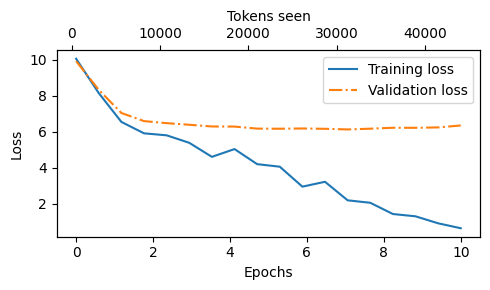

In [130]:
import matplotlib.pyplot as plt
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses,               label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax2 = ax1.twiny()                            # creates second x-axis; shares same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0) # invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()
    
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

- The training and validation losses diverge past the second epoch. This __divergence and the fact that the validation loss is much larger than the training loss indicate that the model is overfitting__.
- We can confirm that the model is memorizing the training data by searching for the generated text snippets. This is expected - we are using a very small training dataset and training the model for multiple epochs.
- It’s common to train a model on a much larger dataset for only one epoch.
- See Appendix B to see how to train the model on 60,000 public domain books from Project Gutenberg.

### 5.3 Decoding strategies to control randomness
- __transfer model back to the CPU - GPU not needed for this small model. 
- after training, put the model into eval model to disable random components such as dropout.

In [131]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

### Plug the GPT model instance into `generate_text_simple`
- It uses the LLM to generate one token at a time.
- The generated token is selected using the largest probability score among all tokens in the vocabulary.
- This means the LLM will generate the same outputs even if we run `generate_text_simple` multiple times on the same start context ("Every effort moves you").

In [132]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model         = model,
    idx           = text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens= 25,
    context_size  = GPT_CONFIG_124M["context_length"])

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




### 5.3.1 Temperature scaling (TS)
- TS __adds a probabilistic selection process__ to next-token generation.
- Previously, `generate_text_simple` always sampled the token with the highest probability as the next token using `torch.argmax` (aka "__greedy decoding__").
- We can replace argmax with a sampling function.
### define very small vocabulary for illustration

In [133]:
vocab = {
"closer": 0,
"every": 1,
"effort": 2,
"forward": 3,
"inches": 4,
"moves": 5,
"pizza": 6,
"toward": 7,
"you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}

### Assume the LLM is given "every effort moves you" and geneates the following next-token logits.

In [134]:
next_token_logits = torch.tensor(
[4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

- `generate_text_simple` converts logits into probabilities via `softmax` and gets the token ID corresponding to the generated token via `argmax`, which we can map back into text via the inverse vocabulary.
- Since the largest logit value, and correspondingly the largest softmax score, is in the fourth position, the generated word is 'forward'.

In [135]:
probas        = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()

print(inverse_vocab[next_token_id])

forward


### replace argmax with PyTorch's [`multinomial`](https://pytorch.org/docs/stable/generated/torch.multinomial.html) method

In [136]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


- `multinomial` samples the next token proportional to its probability score. In other words, "forward" is still the most likely token and will be selected most of the time __but not all the time__.
### repeat this sampling 1,000 times

In [137]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item()
        for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")
print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


- We can control the distribution and selection process via temperature scaling.
- This is just a fancy description for dividing the logits by a number greater than 0.
- Temperatures __greater than 1 return more uniformly distributed token probabilities__.
- Temperatures __smaller than 1 return more confident (sharper or more peaky) distributions__.

In [138]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

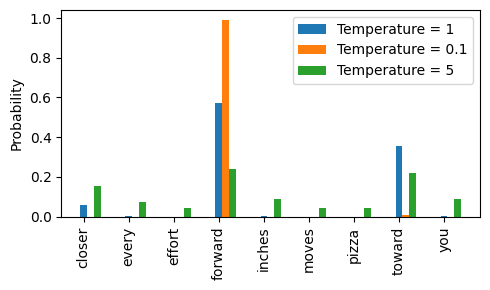

In [139]:
temperatures  = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T)
    for T in temperatures]
x         = torch.arange(len(vocab))
bar_width = 0.15
fig, ax   = plt.subplots(figsize=(5, 3))

for i, T in enumerate(temperatures):
    rects            = ax.bar(x + i * bar_width, scaled_probas[i],
    bar_width, label = f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

- A temperature = 1 divides logits by 1 before passing them to softmax to get probability scores. (In other words, temperature = 1 is the same as not using any temperature scaling.)
    - In this case, the tokens are selected with a probability equal to the original softmax probability scores via PyTorch's multinomial sampling function.
    - The token corresponding to “forward” would be selected about 60% of the time.
- Small temps such as 0.1 returns "sharper" distributions.
    - The multinomial function selects "forward" ~100% of the time - approaching the behavior of argmax.
- Large temps return a __more uniform distribution__.
    - This can add variety to the generated texts but can return nonsensical text.

### 5.3.2 [Top-k](https://pytorch.org/docs/stable/generated/torch.topk.html) sampling
- Temperature scaling can return nonsensical outputs. Top-k sampling, when combined with
probabilistic sampling and temperature scaling, can improve  text generation results.
- Top-k sampling __restricts the sampled tokens to the top-k most likely tokens__ & excludes all others.

<img src="px/fig5-15.png" width="60%">

In [140]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


### get next-token logits in this nine-token vocabulary
- use PyTorch [where](https://pytorch.org/docs/stable/generated/torch.where.html) to set token logit values that are below our top-3 threshold to negative infinity.

In [141]:
new_logits = torch.where(
    condition = next_token_logits < top_logits[-1],
    input     = torch.tensor(float('-inf')),
    other     = next_token_logits)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


### apply softmax to get next-token probabilities

In [142]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### 5.3.3 Modify the text generation function
- includes temperature sampling and top-k sampling.

In [143]:
def generate(model, idx, max_new_tokens, 
             context_size, 
             temperature=0.0, 
             top_k=None,
             eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        
        logits = logits[:, -1, :]
        if top_k is not None: # filter logits with top_k sampling
            top_logits, _ = torch.topk(logits, top_k)
            min_val       = top_logits[:, -1]
            logits        = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits)

        if temperature > 0.0: # temperature scaling
            logits   = logits / temperature
            probs    = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else: # use greedy next-token selection (as before) when TS is disabled
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if idx_next == eos_id: # stop generating early if end-of-sequence token is found,
                               # and eos_id is defined
            break
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

### compare results to `generate_simple` (above)

In [144]:
torch.manual_seed(123)
token_ids = generate(
    model          = model,
    idx            = text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens = 15,
    context_size   = GPT_CONFIG_124M["context_length"],
    top_k          = 25,
    temperature    = 1.4)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know," she down surprise. And whenever to have been an object for enough


### 5.4 Loading and saving model weights in PyTorch
<img src="px/fig5-16.png" width="60%">

- Pretraining is expensive. Saving an LLM means we don’t have to rerun the training every time we want to use it in a new session.
- Saving a PyTorch model is straightforward. Save the model’s `state_dict` (a dictionary mapping each layer to its parameters) with `torch.save`.
- ".pth" is PyTorch's filename convention.
- After saving the model weights we can load them into a new GPTModel model instance.

In [145]:
torch.save(model.state_dict(), "my_model.pth")

In [146]:
!ls *.pth

gpt2-medium355M-sft.pth  model_and_optimizer.pth  review_classifier.pth
gpt2-small124M-sft.pth	 my_model.pth


In [147]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("my_model.pth"))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

- Recall how dropout helps prevent overfitting by randomly “dropping out” of a layer’s neurons during training. We don’t want to lose any learned information during inference. __model.eval()__ switches the model to evaluation mode for inference, disabling the dropout layers of the model.
- __If we plan to continue pretraining a model later__ — we should also save the optimizer state.
- Adaptive optimizers such as __AdamW__ store additional parameters for each model weight. AdamW uses historical data to adjust learning rates for each model parameter dynamically. Without it, the optimizer resets, and the model may learn suboptimally or even fail to converge properly, which means it will lose the ability to generate coherent text.

### `torch.save` saves both the model and optimizer state_dict contents

In [148]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth")

### restore the model and optimizer states with `torch.load` and `load_state_dict`

In [149]:
checkpoint = torch.load("model_and_optimizer.pth")
model      = GPTModel(GPT_CONFIG_124M)

model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

### 5.5 Loading pretrained weights from OpenAI
- We trained a small GPT-2 model using a limited dataset. This allowed us to focus on the fundamentals without the need for extensive time and computational resources.
- OpenAI shared the weights of their GPT-2 models, thus eliminating the need for retraining.
- OpenAI originally saved the GPT-2 weights via __TensorFlow__, which we have to install to load the weights in Python.

### install tqdm (a progress bar tool) to track the download process

In [150]:
#!pip install tensorflow>=2.15.0 tqdm>=4.66

### Download the gpt_download.py Python module from this online repository
- The download code is relatively long, mostly boilerplate, and not very interesting. 

In [151]:
import urllib.request
url = ("https://raw.githubusercontent.com/rasbt/"
       "LLMs-from-scratch/main/ch05/"
       "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x7779ec41e960>)

### inspect the contents of this file to ensure that it was saved correctly and contains valid Python code.
- Import `download_and_load_gpt2` from `gpt_download.py`. It loads the GPT-2 architecture settings (settings) and weight parameters (params) into our Python session.

In [152]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", 
    models_dir="gpt2")

I0000 00:00:1773171322.250597   12943 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773171322.287413   12943 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773171323.165221   12943 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


### inspect the contents of settings and params. Both are Python dictionaries.
- __settings__ stores the LLM architecture settings similarly to our manually defined GPT_CONFIG_124M settings. __params__ contains the actual weight tensors.

In [153]:
print("Settings:\n", settings)
print("Parameter dictionary keys:\n", params.keys())

Settings:
 {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys:
 dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


- We only printed the dictionary keys because printing the weight contents would take up too much screen space.
- We can inspect these weight tensors by printing the whole dictionary via `print(params)`
### print just the embedding layer weight tensor ('wte')

In [154]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


- We're using the weights of the smallest GPT-2 model via `download_and_load_gpt2(model_size="124M", ...)`.
- OpenAI also shares the weights of larger models: 355M, 774M, and 1558M.
- The architecture of these differently sized GPT models is the same, as illustrated in figure 5.17.
<img src="px/fig5-17.png" width="60%">


### create a dictionary that lists the differences between various GPT model sizes

In [155]:
model_configs = {
"gpt2-small (124M)":  {"emb_dim":  768, "n_layers": 12, "n_heads": 12},
"gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
"gpt2-large (774M)":  {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
"gpt2-xl (1558M)":    {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

### use `model_configs` to update our full-length GPT_CONFIG_124M

In [156]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

### update NEW_CONFIG to use a 1024 token length (matching original GPT-2 models from OpenAI)

In [157]:
NEW_CONFIG.update({"context_length": 1024})

- __OpenAI used bias vectors in the multi-head attention module’s linear layers__ to implement the
query, key, and value matrix computations. Bias vectors are not commonly used in LLMs anymore
as they don’t improve the modeling performance and are thus unnecessary.
- However, since we are working with pretrained weights, __we need to match the settings for consistency and enable these bias vectors__:

In [158]:
NEW_CONFIG.update({"qkv_bias": True})

### build a new GPTModel instance

In [159]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

### design an `assign` utility function 
- The GPTModel instance is initialized with random weights by default.
- The last step to using OpenAI’s model weights is to __override these random weights with the weights we loaded into
the params dictionary__.
- it checks whether two tensors or arrays (left and right) have the same dimensions or shape
- it returns the right tensor as trainable PyTorch parameters:

In [160]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, ""Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

### define a function that loads the weights from the params dict into a GPTModel instance.

In [161]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)
        
        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)
        
        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])
        
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])
        
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])
        
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight  = assign(gpt.out_head.weight, params["wte"])

- Here we match the weights from OpenAI’s implementation to our GPTModel implementation.
- Example: OpenAI stored the weight tensor for the output projection layer for the first transformer block as `params["blocks"][0]["attn"]["c_proj"]["w"]`. Our equivalent is `gpt.trf_blocks[b].att.out_proj.weight`, where gpt is a GPTModel instance.
- Developing this function took a lot of guesswork - OpenAI used a slightly different naming convention from ours.
- `assign` should alert us if we try to match two tensors with different dimensions.
- Also: mistakes should be apparent - the GPT model would be unable to produce coherent text.

### launch `load_weights_into_gpt` & load the OpenAI model weights into our GPTModel instance

In [162]:
load_weights_into_gpt(gpt, params)
print(device)
gpt.to(device)

cuda


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

### if loaded correctly, we can now generate new text using our `generate` function:

In [163]:
torch.manual_seed(123)
token_ids = generate(
    model          = gpt,
    idx            = text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens = 25,
    context_size   = NEW_CONFIG["context_length"],
    top_k          = 50,
    temperature    = 1.5)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the hand can go until the end of your turn unless something happens

This would remove you from a battle


---
### 6 Finetuning for Classication
---

### 6.1 classification finetuning vs instruction finetuning
<img src="px/fig6-2.png" width="60%">

- Instruction-finetuning: training a model on a set of tasks __using specific instructions__.

- Classification-finetuning: training a model to recognize a set of class labels, such as "spam" and "not spam." classification-finetuned models are __restricted to predicting classes it has encountered during its training__ — but it can't say anything else about the input text.

- An __instruction-finetuned__ model typically can undertake a broader range of tasks. We can view a classification-finetuned model as highly specialized, and generally, it is easier to develop a specialized model than a generalist model that works well across various tasks.

### 6.2 Preparing the dataset
### download text message dataset with spam and non-spam messages

In [164]:
import urllib.request
import zipfile
import os
from pathlib import Path

url            = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path       = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [165]:
!tree sms_spam_collection

sms_spam_collection
├── readme
└── SMSSpamCollection.tsv

1 directory, 2 files


### load into pandas dataframe

In [166]:
import pandas as pd
df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


### review the class label distribution

In [167]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


### undersample the dataset to include 747 instances from each class for simplicity
- While there are several other methods to handle class imbalances, these are beyond the scope of a book on large language models.

In [168]:
def create_balanced_dataset(df):
    num_spam    = df[df["Label"] == "spam"].shape[0] # count "spams"
    ham_subset  = df[df["Label"] == "ham"].sample(num_spam, random_state=123) # sample "hams" to match #spams
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]]) # combine the two
    return balanced_df
    
balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


### convert class labels to integers (0 and 1)
- This is similar to converting text into token IDs. However, instead of using the GPT vocabulary, which consists of more than 50,000 words, we are dealing with just two token IDs: 0 and 1.

In [169]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

### define random_split function to split the dataset into three parts: 
- 70% for training, 10% for validation, and 20% for testing.

In [170]:
def random_split(df, train_frac, validation_frac):
    
    # shuffle dataframe
    df             = df.sample(frac=1, random_state=123).reset_index(drop=True) 
    # calculate split indices
    train_end      = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)
    #split dataframe
    train_df      = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df       = df[validation_end:]

    return train_df, validation_df, test_df

# test_df size = remainder (0.2)
train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

### save dataset as CSV for later reuse

In [171]:
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

In [172]:
!ls *.csv -s

 32 test.csv  112 train.csv   20 validation.csv


### 6.3 Creating data loaders
- Previously we __used a sliding window__ to generate uniformly sized text chunks, which were then grouped into batches for more efficient model training. Each chunk functioned as an individual training instance.

- The spam dataset contains text messages of varying lengths. To batch these messages, we have two options:
    - __Truncate__ all messages to the length of the shortest message in the dataset or batch.
    - __Pad__ all messages to the length of the longest message in the dataset or batch.

- Truncating is computationally cheaper, but can result in significant information loss if shorter messages are much smaller than the average or longest messages. So, we opt for padding, which preserves the content of all messages.

- __add padding tokens__ (`<|endoftext|>`) to all shorter messages. Instead of appending the string "<|endoftext|>" to each text message, we can add the corresponding token ID.

<img src="px/fig6-6.png" width="60%">

### We assume 50,256 is the token ID of "<|endoftext|>". 
- Verify this by encoding the "<|endoftext|>" using the GPT-2 tokenizer from the tiktoken package.

In [173]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


### define a `SpamDataset` class to handle several key tasks:
- identify the longest sequence in the training dataset
- encode the text messages
- ensure all other sequences are padded with a padding token to match the length of the longest sequence.

In [174]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        
        self.data = pd.read_csv(csv_file)

        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts]

        # pad to longest sequence
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts]
        
    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long))

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

- __SpamDataset__ loads data from the CSV files we created earlier, tokenizes the text using the GPT-2 tokenizer from tiktoken and allows us to pad or truncate the sequences to a uniform length determined by either the longest sequence or a predefined maximum length. This ensures each
input tensor is of the same size, which is necessary to create the batches in the training data loader we implement next:

In [175]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer)

### the longest sequence length is stored in `max_length`

In [176]:
print(train_dataset.max_length)

120


- 120 tokens is a common length for text messages. The model can handle sequences of up to 1,024 tokens, given its context length limit. If your dataset includes longer texts, you can pass `max_length=1024` when creating the training dataset.

### pad the validation and test sets to match the length of the longest training sequence. 
- Any validation and test set samples exceeding the length of the longest training example are truncated using `encoded_text[:self.max_length]` in the `SpamDataset` class.
- This truncation is optional; you could also set `max_length=None` for both validation and test sets, provided there are no sequences exceeding 1,024 tokens in these sets.

In [177]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer)

test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer)

- We can create the data loaders now.
- In this case, the __targets represent class labels__, not the next tokens in the text.
- For instance, for a batch size of 8, each batch will consist of 8 training examples of length 120
and the corresponding class label of each example, as illustrated in figure 6.7.

<img src="px/fig6-7.png" width="60%">

### create the training, validation, and test set data loaders

In [178]:
from torch.utils.data import DataLoader
num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True)

val_loader = DataLoader(
    dataset=val_dataset,   batch_size=batch_size,               num_workers=num_workers, drop_last=False)

test_loader = DataLoader(
    dataset=test_dataset,  batch_size=batch_size,               num_workers=num_workers, drop_last=False)

### verify data loaders are working & returning batches of the expected size 
- iterate over the training loader and then print the tensor dimensions of the last batch.

In [179]:
for input_batch, target_batch in train_loader:
    pass
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


- The input batches consist of 8 training examples with 120 tokens each.
- The label tensor stores the class labels corresponding to the 8 training examples.
### verify dataset size using the total number of batches in each dataset

In [180]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


### 6.4 Initializing a model with pretrained weights

<img src="px/fig6-8.png" width="60%">

### Reuse the configurations from chapter 5:

In [181]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,# Vocabulary size
    "context_length": 1024,# Context length
    "drop_rate": 0.0,# Dropout rate
    "qkv_bias": True# Query-key-value bias
    }

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
    }

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
    )

### reuse `GPTModel` and `load_weights_into_gpt` (chapter 5) to load the weights into the GPT model

In [182]:
from gpt_download import download_and_load_gpt2
#from chapter05 import GPTModel, load_weights_into_gpt

model_size       = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")
model            = GPTModel(BASE_CONFIG)

load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

### use the simple text generation utility to ensure that the model generates coherent text

In [183]:
#from chapter04 import generate_text_simple
#from chapter05 import text_to_token_ids, token_ids_to_text

text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model          = model,
    idx            = text_to_token_ids(text_1, tokenizer),
    max_new_tokens = 15,
    context_size   = BASE_CONFIG["context_length"])

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


### can the model already classify spam messages?

In [184]:
text_2 = (
"Is the following text 'spam'? Answer with 'yes' or 'no':"
" 'You are a winner you have been specially"
" selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
    model          = model,
    idx            = text_to_token_ids(text_2, tokenizer),
    max_new_tokens = 23,
    context_size   = BASE_CONFIG["context_length"])

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


- The model still struggles with following instructions.
- This isn't a surprise - it has undergone only pretraining and lacks instruction-finetuning.

### 6.5 Adding a classification head

- In this section, we modify the pretrained LLM by replacing the original output layer.
- original: maps the hidden representation to a vocabulary of 50,257
- revised: a __smaller output layer that maps to two classes__: 0 ("not spam") and 1 ("spam").

<img src="px/fig6-9.png" width="60%">

### OUTPUT LAYER NODES

- We __could use a single output node__ since we are dealing with a binary classification task.
- This __would require modifying the loss function__. (see Reference section in appendix B.)
- Therefore, we choose a more general approach where the number of output nodes matches the number of classes.
- For example, for a 3-class problem ("Technology", "Sports", or "Politics"), we would use three output nodes.

### print the model architecture via `print(model)`

In [185]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

### FINETUNING SELECTED LAYERS VERSUS ALL LAYERS
- Since we start with a pretrained model, __it's not necessary to finetune all model layers__. The lower layers generally capture basic language structures and semantics that are applicable across a wide range of tasks and
datasets. Finetuning only the last layers (layers near the output), which are more specific task-specific features, can often be sufficient.
- A __nice side effect__ is that it is computationally more efficient to finetune only a small number of layers. See more info in the __References section in appendix B__.

### freeze the model (making it non-trainable)

In [186]:
for param in model.parameters():
    param.requires_grad = False

### replace the output layer (`model.out_head`)
- Originally maps the layer inputs to 50,257 dimensions (the size of the vocabulary).
- Use `BASE_CONFIG["emb_dim"]` (768 in the "gpt2-small (124M)" model) to keep the code flexible.

In [187]:
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes
)

- `model.out_head` has `requires_grad` set to `True` by default. It's the only layer that will be updated during training.
- Training the output layer is sufficient. However, __finetuning additional layers can noticeably improve the predictive performance__ of the model. (See References in appendix C.)
- Also: configure the last transformer block and the final `LayerNorm` module, which connects this block to the output layer, to be trainable.

<img src="px/fig6-10.png" width="60%">

### make final LayerNorm and last transformer block trainable via `requires_grad=True`

In [188]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

### encode inputs into 4-token tensor
- Even though we added a new output layer and marked certain layers as trainable or non-trainable, we can still use this model in a similar way to previous chapters.

In [189]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # shape: (batch_size, num_tokens)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


### pass encoded token IDs to the model

In [190]:
with torch.no_grad():
    outputs = model(inputs)
print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # shape: (batch_size, num_tokens, num_classes)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


- Previously a similar input would have produced an output tensor of [1, 4, 50257], where 50,257 represents the vocabulary size.
- The number of output rows corresponds to the number of input tokens. (in this case, 4).
- Each output's embedding dimension (the number of columns) is now 2. (we replaced the output layer.)
- We want the model to return spam/not spam class labels. We don't need to finetune all 4 output rows but can focus on a single output token.
### extract the last output token

In [191]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


- Why the last output token?
- Recall how __attention mechanism__ establishes a relationship between each input token and every other input token.
- We also designed a __causal attention mask__, common in GPT models, to restricts a token's focus to only its current position and those before it.

<img src="px/fig6-12.png" width="60%">

- The last token in a sequence therefore __accumulates the most information__. (it is the only token with access to data from all the previous tokens.)

### 6.6 classification loss and accuracy
- We previously computed the token ID of the next generated token by converting 50,257 outputs into probabilities via `softmax`, then returning the position of the highest probability via `argmax`.
- Use the same approach to calculate whether the model outputs a "spam" or "not spam" using 2D outputs.
### consider the last token output from above

In [192]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


### corresponding class label:

In [193]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

Class label: 1


- 1 indicates the model predicts that the input text is "spam."
- Softmax is optional because the largest outputs directly correspond to the highest probability scores.
### simplify the code - without softmax

In [194]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


### define a `calc_accuracy_loader` utility
- Classification accuracy is the pct of correct predictions across a dataset.
- Apply the argmax-based prediction code to all samples and calculate the fraction of correct predictions.

In [195]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :] # logits of the last output token
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples        += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

### find classification accuracies across various datasets from 10 batches for efficiency
- uses GPU with CUDA support if available, otherwise uses CPU.

In [196]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

torch.manual_seed(123)

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy   = calc_accuracy_loader(  val_loader, model, device, num_batches=10)
test_accuracy  = calc_accuracy_loader( test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


### Define the loss function to optimize during training. 
- The goal is to maximize spam classification accuracy (the preceding code should return correct class labels: 0 for non-spam and 1 for spam texts).
- __Classification accuracy is not a differentiable function__, so we use __cross entropy loss__ to maximize accuracy.
- `calc_loss_batch` from chapter 5 has one adjustment: we optimize only the last token, `model(input_batch)[:,-1,:]`, instead of all tokens `model(input_batch)`:

- __calc_loss_batch_v2__ differs from chapter 5 - optimizes only the last token instead of all tokens.
- __calc_loss_loader_v2__ finds the loss for all batches in a data loader.

In [197]:
def calc_loss_batch_v2(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits                    = model(input_batch)[:, -1, :]
    loss                      = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

In [198]:
def calc_loss_loader_v2(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss        = calc_loss_batch_v2(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

# compute the initial loss for each data set:
with torch.no_grad():
    train_loss = calc_loss_loader_v2(train_loader, model, device, num_batches=5)
    val_loss   = calc_loss_loader_v2(  val_loader, model, device, num_batches=5)
    test_loss  = calc_loss_loader_v2( test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.453
Validation loss: 2.583
Test loss: 2.322


### 6.7 Finetuning the model on supervised data
- The training loop is the same as in chapter 5.
- The difference is that we find the __classification accuracy__ instead of generating a sample text.
- Track the number of training examples instead of the number of tokens. Find the accuracy after each epoch.

In [199]:
def train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs, eval_freq, eval_iter, tokenizer):
    
    # Initialize lists to track losses and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step                     = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch_v2(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            examples_seen += input_batch.shape[0]
            global_step += 1
    
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy   = calc_accuracy_loader(  val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen


### `evaluate_model` is identical to that used in chap 5.

In [200]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader_v2(train_loader, model, device, num_batches=eval_iter)
        val_loss   = calc_loss_loader_v2(  val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

### Initialize optimizer, set the number of epochs, and start training 
- Use `train_classifier_simple`.

In [201]:
import time
start_time = time.time()
torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs=num_epochs, eval_freq=50, eval_iter=5, tokenizer=tokenizer)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 0.73 mi

### plot the loss function for the training and validation set

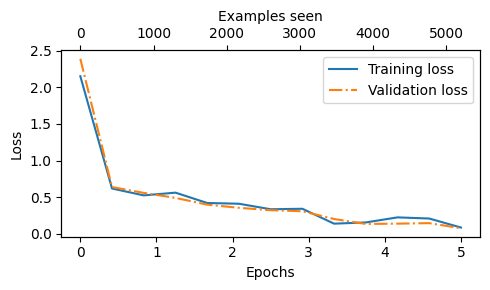

In [202]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("Examples seen")
    fig.tight_layout()
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

epochs_tensor        = torch.linspace(0, num_epochs,    len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

- The model is learning well from the training data
- Little indication of overfitting (no noticeable gap between the training and validation set losses).
### plot the classification accuracies.

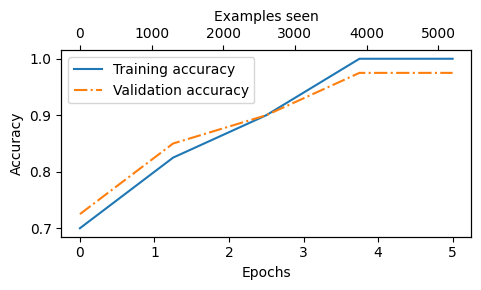

In [203]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))
plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

- High training and validation accuracy after epochs 4 and 5.
- We used __eval_iter=5__ when using __train_classifier_simple__, so estimated performance = based on only 5 batches.
### calculate metrics for training, validation, and test sets across entire dataset.

In [204]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 97.32%
Test accuracy: 95.67%


- Training and test set performances are __almost identical__. A slight discrepancy between the training and test set accuracies suggests minimal overfitting.
- Typical __validation set accuracy is higher than test set accuracy__ - model development often involves tuning hyperparameters to perform well on the validation set, which might not generalize as effectively to the test set.
- __This is common.__ The gap can often be minimized by adjusting the `drop_rate` or `weight_decay` parameters in the optimizer.

### 6.8 Using the LLM as a spam classifier
- Use the finetuned GPT-based spam classification model.
- After converting text into token IDs, the function predicts an integer class label & returns the corresponding class name.

In [205]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()
    input_ids                = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[1]
    input_ids                = input_ids[:min(max_length, supported_context_length)] #B
    input_ids               += [pad_token_id] * (max_length - len(input_ids))
    input_tensor             = torch.tensor(input_ids, device=device).unsqueeze(0) #D
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
    
    predicted_label = torch.argmax(logits, dim=-1).item()
    
    return "spam" if predicted_label == 1 else "not spam"

In [206]:
text_1 = (
"You are a winner you have been specially"
" selected to receive $1000 cash or a $2000 award."
)
print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length))

spam


In [207]:
text_2 = (
"Hey, just wanted to check if we're still on"
" for dinner tonight? Let me know!"
)
print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length))

not spam


### save for later, then reload

In [208]:
torch.save(model.state_dict(), "review_classifier.pth")

In [209]:
model_state_dict = torch.load("review_classifier.pth")
model.load_state_dict(model_state_dict)

<All keys matched successfully>

---
### 7 - Instruction finetuning
---
<img src="px/fig7-1.png" width="60%">

### 7.1 Intro
- LLM pretraining previously meant it learned to generate one word at a time. So it was good at text completion - not much else. Let's teach it how to follow instructions.

<img src="px/fig7-2.png" width="60%">

### 7.2 Preparing a dataset
- The instruction dataset contains __1100 instruction-response pairs__ & was created for this book. More public instruction datasets are in Appendix B.
### design a function to download this dataset. (204KB, JSON format.)

In [210]:
import json
import os
import urllib

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else: # skip if already downloaded
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()
    with open(file_path, "r") as file:
        data = json.load(file)
    return data

file_path = "instruction-data.json"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/instruction-data.json"
data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


- Each item in the `data` list from the JSON file is a dictionary - instruction, input, output. The input field can be empty.

![json-example](px/instruct-tuning-json0-4.png)

In [211]:
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [212]:
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


### input-output pair dataset formats
- Instruction finetuning, aks "supervised instruction finetuning", needs a dataset with __explicit input-output pairs__.
- __There are different data formats__. Below: __two example formats__ that were used for training [Alpaca](https://crfm.stanford.edu/2023/03/13/alpaca.html) and [Phi-3](https://arxiv.org/abs/2404.14219) LLMs.
- We'll use the Alpaca format below.

<img src="px/fig7-4.png" width="60%">

### define a function to convert data entries to Alpaca-style format. 
- It constructs a formatted string from a dict.

In [213]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

### `format_input` skips the Input: section if the input field is empty.

In [214]:
model_input      = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [215]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


### divide dataset into a training (85%), test (10%), and validation sets.

In [216]:
train_portion = int(len(data) * 0.85)  # 85% for training
test_portion  = int(len(data) * 0.1)    # 10% for testing
val_portion   =     len(data) - train_portion - test_portion  # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


### 7.3 Organizing data into training batches
- Previously: __training batches were created automatically__ by the PyTorch DataLoader class, which __uses a default collate function__ to combine lists of samples into batches for training.
- Batching for instruction finetuning __requires a custom collate function__.

<img src="px/fig7-6.png" width="60%">

### Design an __InstructionDataset__ class that __pre-tokenizes all dataset inputs__.
<img src="px/fig7-7.png" width="60%">

In [217]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Pre-tokenize texts
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text          = f"\n\n### Response:\n{entry['output']}"
            full_text              = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

### collect multiple training examples per batch to accelerate training. 
- This requires __padding all inputs to a similar length__.
- Use __<|endoftext|>__, encoded, as a padding token.

In [218]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


### custom batch collator

- We previously padded all examples in a dataset to the same length.
- This time, develop a __custom "collate" function__ to pass to the data loader. It pads the training examples in each batch to have the same length (but different batches can have different lengths).
- This approach minimizes unnecessary padding by only extending sequences to match the longest one in each batch - not the whole dataset.

<img src="px/fig7-8.png" width="60%">

In [219]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        # Pad sequences to max_length
        # this always adds at least 1 additional padding tokens
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        # Remove extra padded token
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    # Convert list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

### verify it's working as intended
- 3 different inputs. Each example should be padded to the same length.

In [220]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


### also need to create __batches with the target token IDs__, corresponding to the batch of input IDs. 
- Target IDs represent what we want the model to generate. They are needed during training to calculate the loss for the weight updates.

<img src="px/fig7-9.png" width="60%" />

### targets are the inputs shifted by 1 position to the right.
- so the LLM can learn to predict the next token.

<img src="px/fig7-10.png" width="400" />

In [221]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item  = item.copy()
        new_item += [pad_token_id] # Add an <|endoftext|> token
        padded    = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs    = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets   = torch.tensor(padded[1:])  # Shift +1 to the right for targets
        
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [222]:
inputs, targets = custom_collate_draft_2(batch)
print("inputs:\n\n",inputs)
print("targets:\n\n",targets)

inputs:

 tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
targets:

 tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


### replace the end-of-text (EOT) tokens
- (previously used as padding tokens; ID# 50256), __with -100 in the target token list__. (Why -100? Stay tuned.)
### leave one EOT token in the target list
- This allows the LLM to learn when to generate an EOT token in response to instructions - this will indicate that the generated response is complete.

<img src="px/fig7-11.png" width="60%">

### modify custom_collate_fn as described above
- also: define `allowed_max_length` to limit the length of the samples (if needed).__ Handy if you use datasets that are longer than the 1024 token context size supported by the GPT-2 model.

In [223]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs and targets
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets

        # New: Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # New: Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [224]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


#### each output logit can correspond to a potential token from the model's vocabulary. 
- Here's how we might calculate cross entropy loss during training when the model predicts a sequence of tokens.

In [225]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],  # 1st training example
     [-0.5, 1.5]]  # 2nd training example
)
targets_1 = torch.tensor([0, 1])

loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


#### adding one training example will, as expected, influence the loss.

In [226]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


### what happens if we replace one of the class labels with -100?

In [227]:
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


- `cross-entropy` ignored the training example with the -100 label__.
- __PyTorch has a default `cross_entropy(..., ignore_index=-100)` setting__ to ignore samples with this label.
- Using this -100 `ignore_index`, __we can ignore the additional end-of-text (padding) tokens in any "padded" batches.
- We still need the first instance of the end-of-text (padding) token (50256). It can signal the LLM when the response is complete.

### masking out target token IDs that correspond to the instruction
- (this is a recommended reader exercise after completing the chapter).

<img src="px/fig7-13.png" width="80%">

- Masking out target token IDs allows cross entropy loss to be computed __only__ for the generated response target IDs.
- This enables the model to focus on generating accurate responses instead of also memorizing instructions (helps avoid overfitting).
- Researchers are divided on whether masking instructions is universally beneficial. For instance, a recent paper ("Instruction Tuning With Loss Over Instructions") shows __not masking instructions helps LLM performance__. (see appendix B). We won't use it in this example.

### 7.4 Creating data loaders for an instruction dataset
<img src="px/fig7-14.png" width="60%">

### initialize device variable ('cpu','cuda','mps')

In [228]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# If you have a Mac with Apple Silicon chip, you can uncomment the next lines of code
# to train the model on the Mac's GPU cores. However, as of this writing, this results in
# larger numerical deviations from the results shown in this chapter, because Apple Silicon
# support in PyTorch is still experimental

# if torch.backends.mps.is_available():
#     device = torch.device("mps")

print("Device:", device)

Device: cuda


### redesigned custom collate function
- use `partial` from Python's `functools` to create a new version of `custom_collate_fn` with the device argument prefilled.
- set `allowed_max_length` to 1024 to match GPT-2 max context length standard.

In [229]:
from functools import partial
customized_collate_fn = partial(custom_collate_fn, device=device, allowed_max_length=1024)

### rebuild data loaders with revised collate function.

In [230]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size  = batch_size,
    collate_fn  = customized_collate_fn,
    shuffle     = True,
    drop_last   = True,
    num_workers = num_workers
)

In [231]:
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size  = batch_size,
    collate_fn  = customized_collate_fn,
    shuffle     = False,
    drop_last   = False,
    num_workers = num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size  = batch_size,
    collate_fn  = customized_collate_fn,
    shuffle     = False,
    drop_last   = False,
    num_workers = num_workers
)

### review dimensions of new input and target batches
- first input & target batches have dimensions of batch_size x 61. 61 = number of tokens in each training example in this batch.

In [232]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

### verify first batch of inputs contains the <|endoftext|> padding tokens (ID=50256)

In [233]:
print(inputs[0])

tensor([21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
          257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
        21017, 46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,
          985,   576,    13,   198,   198, 21017, 23412,    25,   198,   464,
         5156,   318,   845, 13779,    13,   198,   198, 21017, 18261,    25,
          198,   464,  5156,   318,   355, 13779,   355,   257,  4936,    13,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
       device='cuda:0')


### verify first batch of targets contain the "-100" placeholder tokens

In [234]:
print(targets[0])

tensor([  318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,   257,
         2882,   326, 20431, 32543,   262,  2581,    13,   198,   198, 21017,
        46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,   985,
          576,    13,   198,   198, 21017, 23412,    25,   198,   464,  5156,
          318,   845, 13779,    13,   198,   198, 21017, 18261,    25,   198,
          464,  5156,   318,   355, 13779,   355,   257,  4936,    13, 50256,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
       device='cuda:0')


### 7.5 Loading a pretrained LLM
<img src="px/fig7-15.png" width="60%">

### consider loading GPT-2-medium (355M params) instead of GPT-2-small (124M params)
- The 124M model is too small for returning reasonable results via instruction finetuning.
- __Estimated storage needed: 1.42GB!__ (approx 3X that of the smaller model.)

In [235]:
#from gpt_download import download_and_load_gpt2
#from previous_chapters import GPTModel, load_weights_into_gpt

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length reduced from 1024 due to GPU memory capacity
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)":  {"emb_dim":  768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)":  {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)":    {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

#CHOOSE_MODEL = "gpt2-medium (355M)"
CHOOSE_MODEL = "gpt2-small (124M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size       = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")
model            = GPTModel(BASE_CONFIG)

load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


### get baseline pretrained LLM validation performance

In [236]:
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [237]:
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

### Isolate model response from input
- `generate` returns both input and output text (helps with text completion.)
- Isolate the response by subtracting the length of the instruction from the start of the generated_text.

In [238]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Instruction:

Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Instruction:

Convert the active


### the model is not yet following instructions

### 7.6 Finetuning the LLM on instruction data
<img src="px/fig7-16.png" width="60%">

<div style="background-color:mistyrose; border:1px solid red; margin:0.5em; padding: 0.5em;">
    <p>copy calc_loss_batch and calc_loss_loader, from sect 5.1.3, below. They are redefined in chapter 6.</p>
</div>

In [239]:
def calc_loss_batch_v3(input_batch, target_batch, model, device):
    input_batch  = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits       = model(input_batch)
    loss         = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), 
        target_batch.flatten())
    return loss

In [240]:
def calc_loss_loader_v3(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:

        # iterates over all batches, if num_batches isn't specified.
        num_batches = len(data_loader)
    else:
        # reduces #batches to match #batches in the loader, if #batches > #batches in the loader.
        num_batches = min(num_batches, len(data_loader))
        
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch_v3(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches # average loss across all batches

### Check initial training and validation set losses before we start training

In [241]:
print(device)

cuda


In [242]:
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader_v3(train_loader, model, device, num_batches=5)
    val_loss   = calc_loss_loader_v3(  val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 4.167139530181885
Validation loss: 4.0509356498718265


### Estimated runtimes for various devices
- [setups for using cloud GPUs (github/rasbt)](https://github.com/rasbt/LLMs-from-scratch/tree/main/setup)


| Model              | Device                | Runtime for 2 Epochs |
|--------------------|-----------------------|----------------------|
| gpt2-medium (355M) | CPU (M3 MacBook Air)  | 15.78 minutes        |
| gpt2-medium (355M) | GPU (M3 MacBook Air)  | 10.77 minutes        |
| gpt2-medium (355M) | GPU (L4)              | 1.83 minutes         |
| gpt2-medium (355M) | GPU (A100)            | 0.86 minutes         |
| gpt2-small (124M)  | CPU (M3 MacBook Air)  | 5.74 minutes         |
| gpt2-small (124M)  | GPU (M3 MacBook Air)  | 3.73 minutes         |
| gpt2-small (124M)  | GPU (L4)              | 0.69 minutes         |
| gpt2-small (124M)  | GPU (A100)            | 0.39 minutes         |



### Training setup
- initialize optimizer, set epoch count, define eval frequency, define starting context

In [243]:
import os
#os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "caching_allocator"
#os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [244]:
import time
start_time = time.time()
torch.manual_seed(123)

optimizer  = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)
num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 5.67 GiB of which 9.38 MiB is free. Including non-PyTorch memory, this process has 5.60 GiB memory in use. Of the allocated memory 5.28 GiB is allocated by PyTorch, and 174.49 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### plot loss vs epochs

ValueError: x and y must have same first dimension, but have shapes (18,) and (13,)

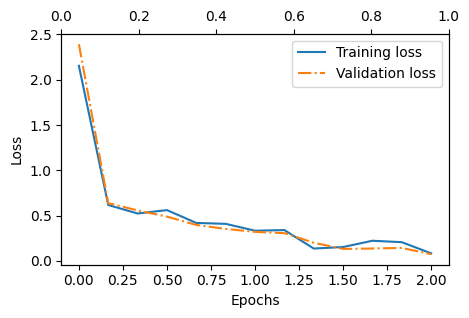

In [245]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

- The loss decreases sharply at the beginning of the first epoch, which means the model starts learning quickly.
- Slight overfitting sets in at around 1 training epoch.

### FINETUNING ON THE ORIGINAL ALPACA DATASET
- The Alpaca dataset (Stanford) is one of the earliest and most popular openly shared instruction datasets. 
- It is available at [https://raw.githubusercontent.com/tatsu-lab/stanford_alpaca/main/alpaca_data.json]
- It contains 52,002 entries (~ 50X our simple example) - most entries are longer as well.
- __Use a GPU to accelerate the finetuning__. If you encounter out-of-memory errors, consider reducing `batch_size` from 8 to 4, 2, or even 1. 
- Also, lowering `allowed_max_length` from 1024 to 512 or 256 can further help manage memory issues.

### 7.7 Extracting and saving responses
- It's time to evaluate model performance on the held-out test set.
- Extract the model-generated responses for each input in the test dataset and collect them for manual analysis.

<img src="px/fig7-18.png" width="60%">

### review the responses generated by the finetuned model

In [246]:
torch.manual_seed(123)

for entry in test_data[:3]: # iterate over first 3 test set samples

    input_text = format_input(entry)

    token_ids = generate(
        model          = model,
        idx            = text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens = 256,
        context_size   = BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text  = generated_text[len(input_text):].replace("### Response:", "").strip()

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 5.67 GiB of which 9.38 MiB is free. Including non-PyTorch memory, this process has 5.60 GiB memory in use. Of the allocated memory 5.29 GiB is allocated by PyTorch, and 174.10 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### observations
- The model performs relatively well. The answers to the first and last instructions are correct.
- The second answer is close ("cumulus cloud" instead of "cumulonimbus")
- __Model evaluation is not as straightforward as before__, where the percentage of correct spam/non-spam class labels gave us a classification accuracy.

<div style="background-color:oldlace; border:1px solid blue; padding:0.5em; margin:0.5em;">
    
- Instruction-finetuned LLMs such as chatbots are __evaluated via multiple approaches__.
    - __MMLU__ ("Measuring Massive Multitask Language Understanding", [https://arxiv.org/abs/2009.03300](https://arxiv.org/abs/2009.03300)) - applicable for __short answers and multiple choices__.
    - __LMSYS chatbot arena__ ([https://arena.lmsys.org](https://arena.lmsys.org)).
    - __AlpacaEval__ ([https://tatsu-lab.github.io/alpaca_eval/](https://tatsu-lab.github.io/alpaca_eval/)), where another LLM like GPT-4 automates the evaluation.

- Consider all three evaluation methods. Since we are interested in conversational performance instead of the ability to answer multiple-choice questions, methods 2 (human evaluation) and 3 (automated metrics) seem more relevant.
</div>

- Human evaluation can be laborious and time-consuming. For instance, reading and assigning ratings to all 1,100 responses would require a significant amount of effort.
- __let's design an approach similar to method 3__, similar to AlpacaEval.
- Instead of relying on a public dataset, we use our own custom test set. This enables a more relevant assessment of the model's performance with our use case.
- Append the generated model responses to the test_set dictionary.
- Save the updated data as "instruction-data-with-response.json".
- Reuse `generate` on the entire test_set. Also, instead of printing the model responses, we add them to the test_set dictionary.

In [247]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input(entry)

    token_ids = generate(
        model          = model,
        idx            = text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens = 256,
        context_size   = BASE_CONFIG["context_length"],
        eos_id         = 50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text

with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing

  0%|                                                | 0/110 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 5.67 GiB of which 9.38 MiB is free. Including non-PyTorch memory, this process has 5.60 GiB memory in use. Of the allocated memory 5.29 GiB is allocated by PyTorch, and 173.70 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### view the first entry to verify responses were added to `test_data` dictionary.

In [ ]:
print(test_data[0])

### Save the model for reuse

In [ ]:
import re

file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# Load model via
# model.load_state_dict(torch.load("gpt2-medium355M-sft.pth"))

In [ ]:
!ls *.pth -s

### 7.8 Evaluating the finetuned LLM
<img src="px/fig7-19.png" width="60%">

### automate the response evaluation of the finetuned LLM using another LLM
- Use an instruction-finetuned __8B param Llama 3__ model by Meta AI. It can be run locally via __ollama__ ([https://ollama.com](https://ollama.com))
- If you prefer using a more capable LLM like GPT-4 via the OpenAI API, see the [llm-instruction-eval-openai.ipynb](https://github.com/rasbt/LLMs-from-scratch/blob/main/ch07/03_model-evaluation/llm-instruction-eval-openai.ipynb) notebook)

### Ollama is an application to run LLMs efficiently
- It is a wrapper around __llama.cpp__ ([https://github.com/ggerganov/llama.cpp](https://github.com/ggerganov/llama.cpp)), which implements LLMs in pure C/C++ to maximize efficiency.
- It uses LLMs to generate text (inference). It is not for training or finetuning LLMs.
- Install ollama by visiting [https://ollama.com](https://ollama.com) and following the instructions.

- macOS and Windows users: click on the ollama application you downloaded; if it prompts you to install the command line usage, say "yes". Linux users can use the installation command provided on the ollama website
- Before using ollama from the command line, start the ollama application or run `ollama serve` in a separate terminal
- Then run the following command to try out the 8B param Llama 3 model. It uses 4.7 GB of storage & will be automatically downloaded the first time you execute this command)

```bash
# 8B model
ollama run llama3
```

The output looks like as follows

```
$ ollama run llama3
pulling manifest
pulling 6a0746a1ec1a... 100% ▕████████████████▏ 4.7 GB
pulling 4fa551d4f938... 100% ▕████████████████▏  12 KB
pulling 8ab4849b038c... 100% ▕████████████████▏  254 B
pulling 577073ffcc6c... 100% ▕████████████████▏  110 B
pulling 3f8eb4da87fa... 100% ▕████████████████▏  485 B
verifying sha256 digest
writing manifest
removing any unused layers
success
```

- Using ollama with `"llama3"` requires 16GB of RAM.
- Replace `llama3` with `phi3` (3.8B params, requires 8GB) if you have memory problems.
- Replace `llama3` with `llama3:70b` (70B param model) if your hardware supports it.
- __you will see a command line prompt__ that allows you to chat with the model.
- __Try a prompt__ like "What do llamas eat?", which should return an output similar to the following

```
>>> What do llamas eat?
Llamas are ruminant animals, which means they have a four-chambered
stomach and eat plants that are high in fiber. In the wild, llamas
typically feed on:
1. Grasses: They love to graze on various types of grasses, including tall
grasses, wheat, oats, and barley.
```

- You can end this session with `/bye`

### verify ollama session is running correctly 
- before using ollama to evaluate the test set responses we previously generated.

In [ ]:
import psutil

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")

if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

<div style="background-color:oldlace; border:1px solid blue; padding:0.5em; margin:0.5em;">

### (optional) running code in a new python session
- loads instruction & response data file (from section 7.7)
- redefines `format_input`

</div>

In [ ]:
import json
from tqdm import tqdm

file_path = "instruction-data-with-response.json"

with open(file_path, "r") as file:
    test_data = json.load(file)


def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

<div style="background-color:oldlace; border:1px solid blue; padding:0.5em; margin:0.5em;">

### Using the `ollama` REST API in Python
- Before running subsequent in this notebook, make sure that ollama is still running (the previous code cells should print `"Ollama running: True"`).

</div>

In [ ]:
import urllib.request

def query_model(prompt, model="phi3", url="http://localhost:11434/api/chat"):
    # Create the data payload as a dictionary
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {     # Settings below are required for deterministic responses
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }

    # Convert the dictionary to a JSON formatted string and encode it to bytes
    payload = json.dumps(data).encode("utf-8")

    # Create a request object, setting the method to POST and adding necessary headers
    request = urllib.request.Request(url, data=payload, method="POST")
    request.add_header("Content-Type", "application/json")

    # Send the request and capture the response
    response_data = ""
    with urllib.request.urlopen(request) as response:
        # Read and decode the response
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]

    return response_data


model = "llama3"
result = query_model("What do Llamas eat?", model)
print(result)

### eval finetuned model responses using `query_model`
- use the first 3 test set responses we looked at in a previous section

In [ ]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")

- conclusion: Llama 3 model reasonable evaluations & gives partial points if a model is not entirely correct. (see  the "cumulus cloud" answer.)
- The previous prompt returns __very verbose evaluations__. We can tweak the prompt to generate integer responses in the range between 0 and 100 (where 100 is best) to find an average score for our model.
- Evaluating 110 entries in the test set takes about 1 minute on an M3 MacBook Air laptop.
### define `generate_model_scores`
- it modifies the prompt to respond with just the integer score.

In [ ]:
def generate_model_scores(json_data, json_key, model="llama3"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores


scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

- The model returns an average score ~48. This is your starting point for benchmarking against other models.
- Possible model performance improvement tactics:
    - Parameter adjustments (learning rate, batch size, epoch count)
    - Dataset adjustments (size, diversity)
    - Prompt adjustments
    - Larger pretrained models (better pattern capture capacity)

- For reference (book notes):
  - Llama 3 8B base model achieves a score of 58.51
  - Llama 3 8B instruct model achieves a score of 82.65

## 7.9 Conclusions

### 7.9.1/2/3 Staying current - additional resources
- [preference finetuning](https://github.com/rasbt/LLMs-from-scratch/tree/main/ch07/04_preference-tuning-with-dpo).
- [Bonus Material](https://github.com/rasbt/LLMs-from-scratch?tab=readme-ov-file#bonus-material)
- [ArXiV cs.LG/recent](https://arxiv.org/list/cs.LG/recent)
- [Reddit Llama page](https://www.reddit.com/r/LocalLLaMA/)
- [Sebastian Raschka magazine](https://magazine.sebastianraschka.com/)
- [axolotl](https://github.com/OpenAccess-AI-Collective/axolotl)
- [LitGPT](https://github.com/Lightning-AI/litgpt)

---
### Appendix A. Introduction to PyTorch
---
- What is PyTorch?
    - Core components
    - Defining deep learning
    - Install
- Tensors
    - Scalars, vectors, matrices, tensors
    - Datatypes
    - Common ops
- Computation graphs
- Auto differentiation
    - Partial derivatives & gradients
- Designing multilayer neural nets
- Data loaders
- Training loops
- Model load/save
- GPU optimization
    - PyTorch on GPUs
    - Single-GPU training
    - Multi-GPU training
    - Selecting available GPUs on a multi-GPU machine
    - Resources

---
### Appendix B. References and Further Reading
---
- Chapter 1
    - [BloombergGPT](https://arxiv.org/abs/2303.17564)
    - [Medical Q&A with LLMs](https://arxiv.org/abs/2305.09617)
    - [Attention is All You Need](https://arxiv.org/abs/1706.03762)
    - [BERT (original encoder-style transformer)](https://arxiv.org/abs/1810.04805)
    - [Decoder-style GPT-3 model](https://arxiv.org/abs/2005.14165)
    - [Original vision transformer](https://arxiv.org/abs/2010.11929)
    - [RWKV (RNN based)](https://arxiv.org/abs/2305.13048)
    - [Hyena (convolution-based)](https://arxiv.org/abs/2302.10866)
    - [Mamba](https://arxiv.org/abs/2312.00752)
    - [Llama2](https://arxiv.org/abs/2307.09288)
    - [The Pile (dataset)](https://arxiv.org/abs/2101.00027)
    - [InstructGPT (GPT finetuning)](https://arxiv.org/abs/2203.02155)
- Chapter 2
    - [Machine Learning Q and AI (Raschka)](https://leanpub.com/machine-learning-q-and-ai/)
    - [Byte pair encoding & tokenization](https://arxiv.org/abs/1508.07909)
    - [BPE tokenizer, used for GPT-2 training](https://github.com/openai/gpt-2/blob/master/src/encoder.py)
    - [BPE tokenizer, interactive UI](https://platform.openai.com/tokenizer)
    - [miniBPE (Karpathy)](https://github.com/karpathy/minbpe)
    - [SentencePiece tokenizer](https://aclanthology.org/D18-2012/)
    - [WordPiece tokenization](https://arxiv.org/abs/2012.15524)
- Chapter 3
    - [Bahdanau attention](https://arxiv.org/abs/1409.0473)
    - [Self attention](https://arxiv.org/abs/1706.03762)
    - [FlashAttention (optimized memory accesses)](https://arxiv.org/abs/2205.14135)
    - [FlashAttention2 (same)](https://arxiv.org/abs/2307.08691)
    - [scaled_dot_product_attention (PyTorch, beta)](https://pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html)
    - [MultiHeadAttention (PyTorch)](https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html)
    - [Dropout](https://jmlr.org/papers/v15/srivastava14a.html)
    - [Simplified Transformer Blocks](https://arxiv.org/abs/2311.01906)
- Chapter 4
    - [Layer normalization](https://arxiv.org/abs/1607.06450)
    - [Pre- vs Post-LayerNorm](https://arxiv.org/abs/2002.04745)
    - [ResiDual Transformer](https://arxiv.org/abs/2304.14802)
    - [Root Mean Square (RMS) Normalization](https://arxiv.org/abs/1910.07467)
    - [Gaussian Error Linear Units (GELUs)](https://arxiv.org/abs/1606.08415)
    - [GPT-3 overview](https://arxiv.org/abs/2005.14165)
    - [GPT-3 overview (Lambda Labs)](https://lambdalabs.com/blog/demystifying-gpt-3)
    - [nanoGPT (Karpathy)](https://github.com/karpathy/nanoGPT)
    - [Computation vs context size](https://www.harmdevries.com/post/context-length/)
- Chapter 5
    - [Logistic Regression Loss Function (YouTube)](https://www.youtube.com/watch?v=GxJe0DZvydM)
    - [Pythia training suite](https://arxiv.org/abs/2304.01373)
    - [OLMo training](https://arxiv.org/abs/2402.00838)
    - [Project Gutenberg Dataset Training](https://github.com/rasbt/LLMs-from-scratch/tree/main/ch05/03_bonus_pretraining_on_gutenberg)
    - 
- Chapter 6
- Chapter 7
- 

---
### Appendix C. Exercise Solutions
---

---
### Appendix D. Adding Bells and Whistles to the Training Loop
---
- Learning rate warmup
- Cosine decay
- Gradient clipping
- Modified training function

---
### Appendix E. Parameter-efficient Finetuning with LoRA
---
- Introduction
- Dataset prep
- Model initialization
- Finetuning

### intro
- LoRA ("low-rank adaptation") adapts a pretrained model to suit a specific, often smaller, dataset by adjusting a subset of the model's weight parameters. The goal is to capture the most influential changes during training.
- Assume a large weight matrix __W__ tied to a specific layer. LoRA can be applied to all linear layers - but focus on a single layer first.
- [ArXiV paper](https://arxiv.org/abs/2106.09685) defines an approximation method to computing weight updates __($\Delta\$W)=AB (AB much smaller than W), so W_new = W+AB.__

<img src="px/fige-1.png" width="60%">

- Keeping the LoRA weights __separate enables model customization without needing to store multiple copies of an LLM__.

### dataset download & prep
- cell copied from section 6.2

In [ ]:
import urllib.request
import zipfile
import os
from pathlib import Path

url            = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path       = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"
'''
def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")
'''

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

df                               = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
balanced_df                      = create_balanced_dataset(df)
balanced_df["Label"]             = balanced_df["Label"].map({"ham": 0, "spam": 1})
train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

In [ ]:
!ls sms*

In [ ]:
!ls *.csv

### create SpamDataset

In [ ]:
import torch
from torch.utils.data import Dataset

### training, validation & test datasets

In [ ]:
import pandas as pd
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

train_dataset = SpamDataset("train.csv",    max_length=None,                     tokenizer=tokenizer)
val_dataset = SpamDataset("validation.csv", max_length=train_dataset.max_length, tokenizer=tokenizer)
test_dataset = SpamDataset("test.csv",      max_length=train_dataset.max_length, tokenizer=tokenizer)

### data loaders

In [ ]:
from torch.utils.data import DataLoader
num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

### verification - iterate data loaders for batch shapes
- 8 training examples. each training example should have 120 tokens.

In [ ]:
print("train loader")
for input_batch, target_batch in train_loader:
    pass
print("input batch dimensions:",input_batch.shape)
print("target batch dimensions:",target_batch.shape)

### verification - number of batches

In [ ]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

### initialize model

In [ ]:
#from gpt_download import download_and_load_gpt2
#from previous_chapters import GPTModel, load_weights_into_gpt

CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"
BASE_CONFIG = {
    "vocab_size": 50257,# Vocabulary size
    "context_length": 1024,# Context length
    "drop_rate": 0.0,# Dropout rate
    "qkv_bias": True# Query-key-value bias
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")
model            = GPTModel(BASE_CONFIG)

load_weights_into_gpt(model, params)
model.eval()

### verify model is loaded correctly. does it generate coherent text?

In [ ]:
text_1    = "Every effort moves you"
token_ids = generate_text_simple(
    model          = model,
    idx            = text_to_token_ids(text_1, tokenizer),
    max_new_tokens = 15,
    context_size   = BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

### prepare model for classification finetuning (similar to chap 6)

In [ ]:
torch.manual_seed(123)
num_classes    = 2
model.out_head = torch.nn.Linear(in_features=768, out_features=num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

### find initial classification accuracy of not-finetuned model

In [ ]:
#from ch06 import calc_accuracy_loader
torch.manual_seed(123)

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy   = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy  = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

### create a LoRA layer
- A & B matrices, `alpha` scaling factor, `rank` setting

<img src="px/fige-2.png" width="60%">

- uses PyTorch's [kaiming_uniform](https://towardsdatascience.com/understand-kaiming-initialization-and-implementation-detail-in-pytorch-f7aa967e9138) initializer
- `rank` governs the inner dimension of matrices A and B. It defines the number of extra parameters introduced by LoRA,
which is used to balance between the adaptability of the model and its efficiency via the number of parameters used.
- `alpha` is a scaling factor for the output from the low-rank adaptation. It dictates the degree to which the output from the adapted layer can impact the original layer's output. It regulates the impact of the low-rank adaptation on the layer's output.
- The typical goal in LoRA is to substitute existing Linear layers, allowing weight updates to be applied directly to the pre-existing pretrained weights.

<img src="px/fige-3.png" width="60%">


In [ ]:
import math

class LoRALayer(torch.nn.Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super().__init__()
        self.A = torch.nn.Parameter(torch.empty(in_dim, rank))
        torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5)) # same initialization used for PyTorch Linear layers
        self.B = torch.nn.Parameter(torch.zeros(rank, out_dim))
        self.alpha = alpha

    def forward(self, x):
        x = self.alpha * (x @ self.A @ self.B)
        return x

### create a LinearWithLoRA layer
- `forward` computes the output by adding the results from the original linear layer and the LoRA layer.
- Since the weight matrix B (`self.B` in `LoRALayer`) is initialized with zeroes, the product of matrices A and B is a zero matrix. __This ensures that the multiplication does not alter the original weights__. (adding zero does not change them.)

In [ ]:
class LinearWithLoRA(torch.nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        self.lora = LoRALayer(linear.in_features, linear.out_features, rank, alpha)

    def forward(self, x):
        return self.linear(x) + self.lora(x)

### define replace_linear_with_lora
- swaps out all existing Linear layers with LinearWithLoRA layers.

In [ ]:
def replace_linear_with_lora(model, rank, alpha):
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            setattr(model, name, LinearWithLoRA(module, rank, alpha))
        else:
            replace_linear_with_lora(module, rank, alpha)

### next: apply LinearWithLoRA upgrade 
- to all Linear layers in multi-head attention, feed-forward modules, and the output layer of the GPTModel.

<img src="px/fige-4.png" width="60%">


### freeze original model params

In [ ]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters before: {total_params:,}")

for param in model.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters after: {total_params:,}")

### replace the Linear layers:
- reduces trainable params by almost 50X.
- A rank and alpha of 16 are good default choices. It's common to increase the rank parameter, which in turn increases the number of trainable parameters. Alpha is usually chosen to be half, double, or equal to the rank.

In [ ]:
replace_linear_with_lora(model, rank=16, alpha=16)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable LoRA parameters: {total_params:,}")

### verify layers have been modified as intended

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(model)

### find initial classification accuracy
- should be identical to the accuracies determined above.

In [ ]:
torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy   = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy  = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

### finetune the model 
- using the training function from chapter 6, renamed to avoid collisions.
- The training takes about 15 minutes on an M3 MacBook Air laptop and less than half a minute on a V100 or A100 GPU:

In [ ]:
def train_classifier_simple_lora(
    model, train_loader, val_loader, optimizer, device,
    num_epochs, eval_freq, eval_iter, tokenizer):
    
    # Initialize lists to track losses and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step                     = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch_v3(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            examples_seen += input_batch.shape[0]
            global_step += 1
    
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy   = calc_accuracy_loader(  val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen


In [ ]:
#from ch06 import train_classifier_simple

import time
start_time = time.time()
torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple_lora(
    model, train_loader, val_loader, optimizer, device, num_epochs=num_epochs, eval_freq=50, eval_iter=5, 
    tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")